# Real-Data ProtoHedge Tests - PyTorch

This notebook is the main workspace for **Axis 1: testing ProtoHedge on real empirical data**.

The goal is not just to make the code run. The goal is to decide whether the PyTorch ProtoHedge pipeline is credible enough for real-data research:

1. Load cleaned empirical hedging episodes.
2. Train vanilla Deep Hedging and ProtoHedge on the same train split.
3. Extract prototypes only from train trajectories, with no train/test leakage.
4. Evaluate on clean validation and test splits.
5. Compare against baselines.
6. Inspect whether learned prototypes correspond to recognizable market states.
7. Stress the model across regimes such as high volatility, selloffs, calm markets, and rallies.

This notebook assumes the cleaned WRDS-derived episode tensor already exists at `Data/training_paths.npy` with shape `[n_paths, n_steps, 5]` and feature order:

`spot`, `call_price`, `call_delta`, `call_vega`, `ivol`.

## How This Maps To The Paper's Empirical-Validation Goal

The ProtoHedge paper says the next crucial step is empirical validation: train on historical market data, test robustness to real frictions and non-stationarity, backtest performance, and check whether prototypes correspond to recognizable market scenarios like crises or flash crashes.

This notebook operationalizes that request as a concrete test bench:

- **Historical dynamics:** We replace `SimpleWorld_Spot_ATM` simulation with `RealWorld_Spot_ATM_Torch` loading empirical episodes.
- **Market frictions:** The real-data world uses spot and option transaction costs from the real-world setup.
- **No leakage:** Splits are explicit; prototypes are extracted from the train split only.
- **Backtest-style holdout:** We report train/validation/test distributions, not just training loss.
- **Interpretability:** We unscale prototypes, inspect their actions, usage, and relation to market states.
- **Regime robustness:** We group test episodes by spot-return and volatility regimes.

For now this is for the current real-data tensor. Later, we should repeat this notebook across tickers, markets, dates, and option types.

## What Means ProtoHedge Works?

ProtoHedge works on real data only if it passes several gates. A single pretty plot is not enough.

**Minimum correctness gates**

- The real-data world loads without NaNs or shape mismatches.
- Vanilla and ProtoHedge training produce finite `utility`, `utility0`, `pnl`, `gains`, `actions`, and `payoff`.
- Prototype extraction produces a payload with `prototypes` and `scaler`.
- Prototype dimensions match the model input features.
- Prototype extraction is fit only on training trajectories.
- Evaluation uses held-out validation/test paths.

**Economic-validity gates**

- Real prices are optionally normalized by initial spot so the empirical world is on the same scale as the original synthetic worlds.
- The default real-data test uses `hedge_mode="terminal"`, which matches the original Deep Hedging convention: an action at time `t` is a trade whose P&L is evaluated to the hedge horizon.
- Cumulative position bounds are optional market constraints, not a change to ProtoHedge's architecture. They prevent the neural network from turning a hedging experiment into an unconstrained leveraged directional trading strategy.

**Performance gates**

- ProtoHedge should improve over unhedged payoff on test utility and downside/tail metrics.
- ProtoHedge should be competitive with vanilla Deep Hedging on held-out test data under the same market constraints.
- ProtoHedge should also be compared with a simple empirical spot-delta baseline.
- It does not need to beat vanilla in every tiny run, but if it consistently underperforms after tuning, the prototype bottleneck is not working for this dataset.

**Interpretability gates**

- Frequently used prototypes should correspond to coherent market states.
- Prototype actions should be financially plausible, stable, and not just arbitrary saturation at action bounds.
- Similar market states should activate similar prototypes.

**Robustness gates**

- Results should not collapse in high-volatility, selloff, or other stress regimes.
- Prototype usage should shift in understandable ways across regimes.
- Results should remain qualitatively stable across seeds, prototype counts, and train/test splits.

## Testing Roadmap For Axis 1

Your project roadmap is:

1. **Gather Data from WRDS** - done outside this notebook.
2. **Clean the data and extract what we need** - produces `Data/training_paths.npy`.
3. **Extract hedging episodes** - paths shaped `[episode, step, feature]`.
4. **Integrate data into ProtoHedge** - handled by `RealWorld_Spot_ATM_Torch` and `run_train_torch.py`.
5. **Run ProtoHedge on real data** - this notebook.
6. **Compare with baselines** - unhedged, vanilla Deep Hedging, and later classical delta-style baselines.
7. **Analyze learned prototypes** - prototype tables, action maps, usage heatmaps.
8. **Backtest performance** - out-of-sample gains, tail risk, CVaR-style summaries.
9. **Evaluate market regimes** - return and volatility buckets.
10. **Repeat across tickers/markets/models** - future extension once this single-dataset harness is stable.

## 0. Setup

Run this notebook from the repo root or from `notebooks/`. The path setup below handles both.

In [138]:
from pathlib import Path
import sys
import json
import pickle
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

cwd = Path.cwd().resolve()
REPO_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
REPO_PARENT = REPO_ROOT.parent

# Hard guard: this notebook must use the local repo files, not an installed
# deephedging package and not classes cached from an earlier kernel state.
assert (REPO_ROOT / "world_real_torch.py").exists(), f"Could not find local repo module at {REPO_ROOT / 'world_real_torch.py'}"

repo_parent_str = str(REPO_PARENT)
sys.path = [p for p in sys.path if Path(p or ".").resolve() != REPO_PARENT]
sys.path.insert(0, repo_parent_str)

# Force a fresh import of all local deephedging modules. This is deliberately
# stronger than importlib.reload because a stale kernel may already have loaded
# deephedging from a different path or with older class definitions.
for module_name in list(sys.modules):
    if module_name == "deephedging" or module_name.startswith("deephedging."):
        del sys.modules[module_name]

from deephedging.base_torch import torchCast
from deephedging.prototype_extraction_torch import build_prototype_payload, save_prototype_payload
from deephedging.run_train_torch import run_experiment
from deephedging.world_real_torch import RealWorld_Spot_ATM_Torch
import deephedging.world_real_torch as world_real_torch
import deephedging.run_train_torch as run_train_torch

world_module_path = Path(world_real_torch.__file__).resolve()
expected_world_module_path = (REPO_ROOT / "world_real_torch.py").resolve()
assert world_module_path == expected_world_module_path, (
    "Imported the wrong world_real_torch.py. "
    f"Expected {expected_world_module_path}, got {world_module_path}. "
    "Restart the kernel and run this setup cell first."
)

pd.set_option("display.max_columns", 80)
plt.rcParams["figure.figsize"] = (9, 5)

print("repo root:", REPO_ROOT)
print("repo parent first on sys.path:", sys.path[0])
print("torch:", torch.__version__)
print("RealWorld module:", world_module_path)
print("run_train_torch module:", Path(run_train_torch.__file__).resolve())

repo root: /Users/yaniszaim/deephedging
repo parent first on sys.path: /Users/yaniszaim
torch: 2.5.1
RealWorld module: /Users/yaniszaim/deephedging/world_real_torch.py
run_train_torch module: /Users/yaniszaim/deephedging/run_train_torch.py


## 1. Experiment Configuration

The early notebook sections stay in quick-diagnostic mode so `Run All` does not waste hours duplicating the full sweep model-by-model. The serious empirical result now comes from the sweep section at the end, which is configured to launch the full 800-epoch step-mode experiment when you run the notebook.

In [139]:
DATA_PATH = REPO_ROOT / "Data" / "training_paths.npy"
OUTPUT_DIR = REPO_ROOT / ".deephedging_real_runs" / "notebook_real_data_step_diagnostics"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 1234
SAMPLES = 512       # Keep the early notebook sections light; the sweep section below runs on all paths.
EPOCHS = 5          # Quick diagnostics only. The full empirical sweep below uses 800 epochs.
N_PROTOTYPES = 25
BATCH_SIZE = None   # None means the trainer uses its default mini-batch behavior.
LR = 1e-3
MAX_POINTS = None   # Optional cap for KMeans prototype extraction rows.

TRAIN_FRAC = 0.70
VAL_FRAC = 0.15

# Real-data environment controls. These are market/environment choices, not
# changes to the ProtoHedge architecture.
NORMALIZE_REAL_WORLD = True
HEDGE_MODE = "step"           # Match the original TensorFlow real-data world (`world_real.py`) one-step hedge increments.
USE_POSITION_BOUNDS = True

# Per-trade bounds remain close to the original action-bound mechanism.
TRADE_BOUNDS = {
    "lbnd_as": -5.0,
    "ubnd_as": 5.0,
    "lbnd_av": -5.0,
    "ubnd_av": 5.0,
}

# Cumulative position bounds prevent leveraged directional trading while still
# allowing the model to choose its hedge. Tune later as a robustness check.
POSITION_BOUNDS = {
    "lbnd_delta_s": -2.0,
    "ubnd_delta_s": 2.0,
    "lbnd_delta_v": -2.0,
    "ubnd_delta_v": 2.0,
}

FEATURE_ORDER_IN_FILE = ["spot", "call_price", "call_delta", "call_vega", "ivol"]
MODEL_FEATURES = ["price", "delta", "time_left"]

print("data:", DATA_PATH)
print("output:", OUTPUT_DIR)
print("normalize:", NORMALIZE_REAL_WORLD)
print("hedge_mode:", HEDGE_MODE)
print("position_bounds:", USE_POSITION_BOUNDS, POSITION_BOUNDS if USE_POSITION_BOUNDS else None)

data: /Users/yaniszaim/deephedging/Data/training_paths.npy
output: /Users/yaniszaim/deephedging/.deephedging_real_runs/notebook_real_data_pilot
normalize: True
hedge_mode: terminal
position_bounds: True {'lbnd_delta_s': -2.0, 'ubnd_delta_s': 2.0, 'lbnd_delta_v': -2.0, 'ubnd_delta_v': 2.0}


## 2. Load And Validate The Real Dataset

The current real-data tensor should have shape `[n_paths, 20, 5]`. The five columns are expected to be spot, call price, call delta, call vega, and implied volatility.

In [140]:
paths = np.load(DATA_PATH, mmap_mode="r")
print("shape:", paths.shape)
print("dtype:", paths.dtype)

assert paths.ndim == 3, f"Expected [paths, steps, features], got {paths.shape}"
assert paths.shape[-1] >= 5, f"Expected at least 5 features, got {paths.shape[-1]}"
assert np.isfinite(paths).all(), "Real-data tensor contains NaN or infinite values"

summary_rows = []
for i, name in enumerate(FEATURE_ORDER_IN_FILE):
    x = np.asarray(paths[:, :, i])
    summary_rows.append({
        "feature": name,
        "mean": float(np.mean(x)),
        "std": float(np.std(x)),
        "min": float(np.min(x)),
        "p01": float(np.quantile(x, 0.01)),
        "p50": float(np.quantile(x, 0.50)),
        "p99": float(np.quantile(x, 0.99)),
        "max": float(np.max(x)),
    })

data_summary = pd.DataFrame(summary_rows)
display(data_summary)

shape: (4485, 20, 5)
dtype: float64


,feature,mean,std,min,p01,p50,p99,max
0,spot,247.681312,127.162452,68.110000,83.680000,208.970000,573.760010,607.810000
1,call_price,107.492528,87.317232,3.870000,9.305000,77.525000,351.690000,483.020000
2,call_delta,0.993802,0.011497,0.748129,0.951260,0.996863,0.999951,0.999994
3,call_vega,0.930705,1.197486,0.000083,0.008794,0.521673,6.160625,16.427170
4,ivol,0.936722,0.899986,0.083625,0.127532,0.646663,4.453875,8.474846


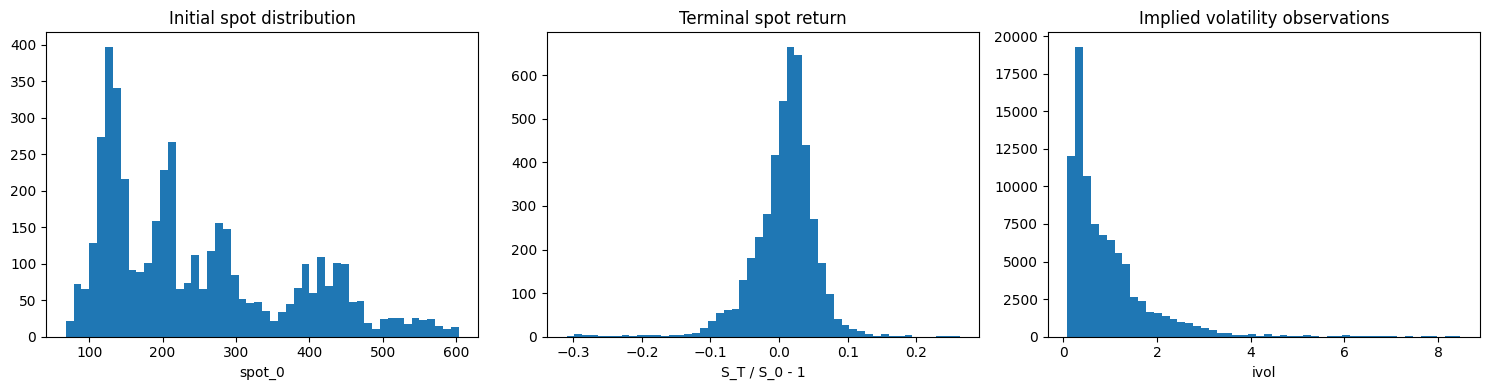

In [141]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(np.asarray(paths[:, 0, 0]), bins=50)
axes[0].set_title("Initial spot distribution")
axes[0].set_xlabel("spot_0")

terminal_return = np.asarray(paths[:, -1, 0] / paths[:, 0, 0] - 1.0)
axes[1].hist(terminal_return, bins=50)
axes[1].set_title("Terminal spot return")
axes[1].set_xlabel("S_T / S_0 - 1")

axes[2].hist(np.asarray(paths[:, :, 4]).reshape(-1), bins=50)
axes[2].set_title("Implied volatility observations")
axes[2].set_xlabel("ivol")

plt.tight_layout()
plt.show()

## 3. Train / Validation / Test Split

Splits are explicit arrays of path indices. This matters because prototypes must be extracted from the training split only.

In [142]:
def split_indices(n_paths, train_frac=0.70, val_frac=0.15, seed=1234, samples=None):
    if train_frac <= 0 or val_frac <= 0 or train_frac + val_frac >= 1:
        raise ValueError("Require train_frac > 0, val_frac > 0, and train_frac + val_frac < 1")

    rng = np.random.default_rng(seed)
    idx = rng.permutation(int(n_paths))
    if samples is not None:
        samples = int(samples)
        if samples <= 2:
            raise ValueError("samples must leave room for train, validation, and test splits")
        idx = idx[:samples]

    n = len(idx)
    n_train = max(1, int(np.floor(n * train_frac)))
    n_val = max(1, int(np.floor(n * val_frac)))
    if n_train + n_val >= n:
        raise ValueError("No test paths left; increase samples or reduce split fractions")

    return {
        "train": idx[:n_train].astype(np.int64),
        "val": idx[n_train:n_train+n_val].astype(np.int64),
        "test": idx[n_train+n_val:].astype(np.int64),
    }

splits = split_indices(paths.shape[0], TRAIN_FRAC, VAL_FRAC, SEED, SAMPLES)
np.savez(OUTPUT_DIR / "splits.npz", **splits)

split_df = pd.DataFrame({"split": list(splits), "n_paths": [len(v) for v in splits.values()]})
display(split_df)
print("saved:", OUTPUT_DIR / "splits.npz")

,split,n_paths
0,train,358
1,val,76
2,test,78


saved: /Users/yaniszaim/deephedging/.deephedging_real_runs/notebook_real_data_pilot/splits.npz


## 4. Helper Functions

These helpers keep the notebook state explicit. The important point: `world_cfg(..., val_indices=...)` passes a true validation split into `run_experiment`.

In [143]:
REQUIRED_RESULT_KEYS = ["utility", "utility0", "pnl", "gains", "actions", "payoff"]
SUMMARY_KEYS = ["utility", "utility0", "gains", "payoff", "pnl", "cost"]


def as_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def world_cfg(indices, val_indices=None):
    cfg = {
        "world_type": "real",
        "data_path": str(DATA_PATH),
        "sample_indices": [int(i) for i in indices],
        "shuffle": False,
        "seed": int(SEED),
        "normalize": bool(NORMALIZE_REAL_WORLD),
        "hedge_mode": HEDGE_MODE,
        "position_bounds": bool(USE_POSITION_BOUNDS),
        **TRADE_BOUNDS,
    }
    if USE_POSITION_BOUNDS:
        cfg.update(POSITION_BOUNDS)
    if val_indices is not None:
        cfg["val_sample_indices"] = [int(i) for i in val_indices]
    return cfg


def training_cfg(epochs=EPOCHS):
    return {
        "epochs": int(epochs),
        "lr": float(LR),
        "batch_size": BATCH_SIZE,
        "epoch_refresh": max(1, int(epochs)),
        "clipvalue": 1.0,
        "global_clipnorm": 1.0,
        "lr_decay_factor": None,
        "lr_decay_patience": None,
    }


def objective_cfg():
    return {"risk_measure": "cvar", "risk_aversion": 1.0}


def vanilla_model_cfg():
    return {
        "agent_type": "feed_forward",
        "feature_list": MODEL_FEATURES,
        "network_width": 20,
        "network_depth": 3,
        "activation": "softplus",
    }


def proto_model_cfg(prototype_path):
    return {
        "agent_type": "protopnet",
        "prototype_path": str(prototype_path),
        "feature_list": MODEL_FEATURES,
        "weighted_similarity": True,
        "learn_distance_feature_weights": False,
    }


def assert_finite_result(label, result):
    for key in REQUIRED_RESULT_KEYS:
        assert key in result, f"{label}: missing result['{key}']"
        values = as_numpy(result[key])
        assert np.isfinite(values).all(), f"{label}: non-finite values in result['{key}']"


def assert_finite_baseline(label, result):
    for key in ["pnl", "gains", "actions", "payoff", "cost"]:
        assert key in result, f"{label}: missing result['{key}']"
        values = as_numpy(result[key])
        assert np.isfinite(values).all(), f"{label}: non-finite values in result['{key}']"


def summarize_result(result):
    metrics = {}
    for key in SUMMARY_KEYS:
        if key not in result:
            continue
        values = as_numpy(result[key]).reshape(-1)
        metrics[f"{key}_mean"] = float(np.mean(values))
        metrics[f"{key}_std"] = float(np.std(values))
        metrics[f"{key}_p01"] = float(np.quantile(values, 0.01))
        metrics[f"{key}_p05"] = float(np.quantile(values, 0.05))
        metrics[f"{key}_p50"] = float(np.quantile(values, 0.50))
        metrics[f"{key}_p95"] = float(np.quantile(values, 0.95))
        metrics[f"{key}_p99"] = float(np.quantile(values, 0.99))

    if "actions" in result:
        actions = as_numpy(result["actions"])
        metrics["action_abs_mean"] = float(np.mean(np.abs(actions)))
        metrics["action_abs_max"] = float(np.max(np.abs(actions)))
        metrics["action_shape"] = list(actions.shape)
    if "deltas" in result:
        deltas = as_numpy(result["deltas"])
        metrics["delta_abs_mean"] = float(np.mean(np.abs(deltas)))
        metrics["delta_abs_max"] = float(np.max(np.abs(deltas)))
    return metrics


def evaluate_gym(gym, indices, label):
    world = RealWorld_Spot_ATM_Torch(world_cfg(indices))
    data = torchCast(world.torch_data)
    gym.eval()
    with torch.no_grad():
        result = gym.forward(data, training=False, return_paths=True)
    assert_finite_result(label, result)
    result = {k: v.detach().cpu() if isinstance(v, torch.Tensor) else v for k, v in result.items()}
    metrics = summarize_result(result)
    metrics.update({"n_paths": int(world.nSamples), "n_steps": int(world.nSteps), "n_inst": int(world.nInst)})
    return world, result, metrics


def evaluate_unhedged(indices):
    world = RealWorld_Spot_ATM_Torch(world_cfg(indices))
    payoff = np.asarray(world.data.market.payoff, dtype=np.float32)
    n_paths, n_steps, n_inst = world.data.market.hedges.shape
    result = {
        "payoff": payoff,
        "pnl": np.zeros_like(payoff),
        "cost": np.zeros_like(payoff),
        "gains": payoff.copy(),
        "actions": np.zeros((n_paths, n_steps, n_inst), dtype=np.float32),
        "deltas": np.zeros((n_paths, n_steps, n_inst), dtype=np.float32),
    }
    assert_finite_baseline("unhedged", result)
    metrics = summarize_result(result)
    metrics.update({"n_paths": int(world.nSamples), "n_steps": int(world.nSteps), "n_inst": int(world.nInst)})
    return world, result, metrics


def evaluate_spot_delta_baseline(indices):
    """Spot-only empirical delta hedge under the same world/gym accounting.

    For a short call, a simple hedge holds a long spot position close to the
    empirical call delta. Actions are trades into that target cumulative
    position, then the same transaction costs and optional position bounds are
    applied as the neural models.
    """
    world = RealWorld_Spot_ATM_Torch(world_cfg(indices))
    market = world.data.market
    hedges = np.asarray(market.hedges, dtype=np.float32)
    trading_cost = np.asarray(market.cost, dtype=np.float32)
    payoff = np.asarray(market.payoff, dtype=np.float32)
    ubnd_a = np.asarray(market.ubnd_a, dtype=np.float32)
    lbnd_a = np.asarray(market.lbnd_a, dtype=np.float32)
    ubnd_delta = np.asarray(market.ubnd_delta, dtype=np.float32) if "ubnd_delta" in market else None
    lbnd_delta = np.asarray(market.lbnd_delta, dtype=np.float32) if "lbnd_delta" in market else None

    call_delta = np.asarray(world.data.features.per_step["call_delta"], dtype=np.float32)
    n_paths, n_steps, n_inst = hedges.shape
    delta = np.zeros((n_paths, n_inst), dtype=np.float32)
    actions = np.zeros((n_paths, n_steps, n_inst), dtype=np.float32)
    deltas = np.zeros((n_paths, n_steps, n_inst), dtype=np.float32)
    pnl = np.zeros((n_paths,), dtype=np.float32)
    cost = np.zeros((n_paths,), dtype=np.float32)

    for t in range(n_steps):
        target_delta = np.zeros_like(delta)
        target_delta[:, 0] = call_delta[:, t]
        if ubnd_delta is not None and lbnd_delta is not None:
            target_delta = np.minimum(np.maximum(target_delta, lbnd_delta[:, t, :]), ubnd_delta[:, t, :])

        action = target_delta - delta
        action = np.minimum(np.maximum(action, lbnd_a[:, t, :]), ubnd_a[:, t, :])
        if ubnd_delta is not None and lbnd_delta is not None:
            bounded_delta = np.minimum(np.maximum(delta + action, lbnd_delta[:, t, :]), ubnd_delta[:, t, :])
            action = bounded_delta - delta

        pnl += np.sum(action * hedges[:, t, :], axis=1)
        cost += np.sum(np.abs(action) * trading_cost[:, t, :], axis=1)
        delta += action
        actions[:, t, :] = action
        deltas[:, t, :] = delta

    result = {
        "payoff": payoff,
        "pnl": pnl,
        "cost": cost,
        "gains": payoff + pnl - cost,
        "actions": actions,
        "deltas": deltas,
    }
    assert_finite_baseline("spot_delta", result)
    metrics = summarize_result(result)
    metrics.update({"n_paths": int(world.nSamples), "n_steps": int(world.nSteps), "n_inst": int(world.nInst)})
    return world, result, metrics


def metrics_to_df(metrics):
    rows = []
    for model_name, split_metrics in metrics.items():
        for split_name, values in split_metrics.items():
            row = {"model": model_name, "split": split_name}
            row.update({k: v for k, v in values.items() if not isinstance(v, list)})
            rows.append(row)
    return pd.DataFrame(rows)

## 5. RealWorld Construction Smoke Test

Before training, verify the world exposes the objects expected by `DeepHedgingGymTorch`.

In [144]:
smoke_cfg = world_cfg(splits["train"][:min(32, len(splits["train"]))])
print("RealWorld class module:", RealWorld_Spot_ATM_Torch.__module__)
print("RealWorld module file:", Path(sys.modules[RealWorld_Spot_ATM_Torch.__module__].__file__).resolve())
print("smoke world cfg:", {k: smoke_cfg[k] for k in ["normalize", "hedge_mode", "position_bounds"] if k in smoke_cfg})

smoke_world = RealWorld_Spot_ATM_Torch(smoke_cfg)
print("nSamples:", smoke_world.nSamples)
print("nSteps:", smoke_world.nSteps)
print("nInst:", smoke_world.nInst)
print("normalize:", getattr(smoke_world, "normalize", None))
print("hedge_mode:", getattr(smoke_world, "hedge_mode", None))
print("position_bounds:", getattr(smoke_world, "position_bounds", None))
print("hedges:", smoke_world.data.market.hedges.shape)
print("cost:", smoke_world.data.market.cost.shape)
print("price feature:", smoke_world.data.features.per_step["price"].shape)
print("payoff:", smoke_world.data.market.payoff.shape)
print("inst_names:", smoke_world.inst_names)

if NORMALIZE_REAL_WORLD:
    if smoke_cfg.get("normalize") is not True:
        raise RuntimeError(f"world_cfg did not set normalize=True. smoke_cfg={smoke_cfg}")
    if getattr(smoke_world, "normalize", None) is not True:
        raise RuntimeError(
            "NORMALIZE_REAL_WORLD=True, but RealWorld_Spot_ATM_Torch did not report normalize=True. "
            "Restart the notebook kernel, then run cells from the top so the updated world_real_torch.py is reloaded."
        )
    initial_spot = np.asarray(smoke_world.data.features.per_step["spot"][:, 0])
    if not np.allclose(initial_spot, 1.0, rtol=1e-6, atol=1e-6):
        raise AssertionError(
            "Expected normalized initial spot to equal 1.0, but got raw-looking values. "
            f"First five spot_0 values: {initial_spot[:5]}. "
            f"RealWorld class file: {Path(sys.modules[RealWorld_Spot_ATM_Torch.__module__].__file__).resolve()}. "
            "This means the notebook is still using stale code or an older open copy of the notebook. "
            "Save/reload this notebook file in Jupyter, restart the kernel, and run the setup cell first."
        )
    print("normalization check: spot_0 == 1")

if USE_POSITION_BOUNDS:
    assert "ubnd_delta" in smoke_world.data.market
    assert "lbnd_delta" in smoke_world.data.market
    print("position bounds check:", smoke_world.data.market.lbnd_delta[0, 0, :], smoke_world.data.market.ubnd_delta[0, 0, :])

# Payoff should be short ATM-start call in the chosen price scale.
spot = smoke_world.data.features.per_step["spot"]
expected_payoff = -np.maximum(spot[:, -1] - spot[:, 0], 0.0)
np.testing.assert_allclose(smoke_world.data.market.payoff, expected_payoff, rtol=1e-5, atol=1e-6)
print("payoff check: ok")

RealWorld class module: deephedging.world_real_torch
RealWorld module file: /Users/yaniszaim/deephedging/world_real_torch.py
smoke world cfg: {'normalize': True, 'hedge_mode': 'terminal', 'position_bounds': True}
nSamples: 32
nSteps: 20
nInst: 2
normalize: True
hedge_mode: terminal
position_bounds: True
hedges: (32, 20, 2)
cost: (32, 20, 2)
price feature: (32, 20, 2)
payoff: (32,)
inst_names: ['spot', 'ATM Call']
normalization check: spot_0 == 1
position bounds check: [-2. -2.] [2. 2.]
payoff check: ok


## 5b. Environment Semantics And Baselines

This notebook now defaults to the stricter empirical setup we want for real-data testing:

- `NORMALIZE_REAL_WORLD=True` divides spot, call price, call vega, hedge P&L, costs, and payoff by each path's initial spot. This puts empirical paths on the same rough scale as the original synthetic worlds.
- `HEDGE_MODE="terminal"` makes hedge P&L follow the original Deep Hedging convention: a trade at time `t` is evaluated to the hedge horizon, matching the synthetic world design. The previous raw real-data smoke mode used one-step increments and remains available as `HEDGE_MODE="step"`.
- `USE_POSITION_BOUNDS=True` adds cumulative position constraints as market data. The agent architecture and ProtoHedge similarity mechanism are unchanged; both vanilla and ProtoHedge simply trade inside the same admissible market.
- The empirical spot-delta baseline below uses the same world accounting and costs, so it is a fairer baseline than eyeballing raw payoff alone.

In [145]:
# Quick baseline smoke checks before training neural models.
_, unhedged_smoke, unhedged_smoke_metrics = evaluate_unhedged(splits["train"][:min(64, len(splits["train"]))])
_, delta_smoke, delta_smoke_metrics = evaluate_spot_delta_baseline(splits["train"][:min(64, len(splits["train"]))])

display(pd.DataFrame([
    {"baseline": "unhedged", **unhedged_smoke_metrics},
    {"baseline": "spot_delta", **delta_smoke_metrics},
])[["baseline", "gains_mean", "gains_p05", "gains_p50", "action_abs_mean", "delta_abs_max"]])

,baseline,gains_mean,gains_p05,gains_p50,action_abs_mean,delta_abs_max
0,unhedged,-0.020729,-0.065083,-0.010944,0.000000,0.000000
1,spot_delta,-0.017123,-0.066510,-0.000569,0.027466,0.999994


## 6. Train Vanilla Deep Hedging On Real Data

This is the non-prototype neural baseline. ProtoHedge should be compared against this, not only against the unhedged payoff.

In [146]:
results_real_vanilla = run_experiment(
    override_world=world_cfg(splits["train"], val_indices=splits["val"]),
    override_model=vanilla_model_cfg(),
    override_objective=objective_cfg(),
    override_training=training_cfg(EPOCHS),
)


PyTorch version 2.5.1 running on 8 CPUs and 0 GPUs
epoch 0 | batch 0.4151 | train 0.4098 | val 0.4364


## 7. Extract Real-Data Prototypes From Train Split Only

This is where leakage can accidentally creep in. We use `results_real_vanilla["world"]`, which is the train world, and `results_real_vanilla["training_result"]`, which is the train trajectory output.

In [147]:
prototype_payload = build_prototype_payload(
    world=results_real_vanilla["world"],
    result=results_real_vanilla["training_result"],
    n_prototypes=N_PROTOTYPES,
    feature_names=MODEL_FEATURES,
    random_state=SEED,
    max_points=MAX_POINTS,
)

prototype_path = OUTPUT_DIR / f"real_train_prototypes_{N_PROTOTYPES}.pkl"
save_prototype_payload(prototype_payload, prototype_path)

print("prototype path:", prototype_path)
print("prototype shape:", np.asarray(prototype_payload["prototypes"]).shape)
print("feature names:", prototype_payload.get("feature_names"))
print("input dim:", prototype_payload.get("input_dim"))
assert "scaler" in prototype_payload
assert np.asarray(prototype_payload["prototypes"]).shape[1] == 5

prototype path: /Users/yaniszaim/deephedging/.deephedging_real_runs/notebook_real_data_pilot/real_train_prototypes_25.pkl
prototype shape: (25, 5)
feature names: ['delta', 'price', 'time_left']
input dim: 5


## 8. Train ProtoHedge On Real Data

The ProtoHedge model uses the same train/validation splits as vanilla, but with the train-only prototype payload.

In [148]:
results_real_proto = run_experiment(
    override_world=world_cfg(splits["train"], val_indices=splits["val"]),
    override_model=proto_model_cfg(prototype_path),
    override_objective=objective_cfg(),
    override_training=training_cfg(EPOCHS),
)


PyTorch version 2.5.1 running on 8 CPUs and 0 GPUs
epoch 0 | batch 0.0887 | train 0.0790 | val 0.0696


## 9. Evaluate Clean Train / Validation / Test Splits

This is the first real acceptance gate. We evaluate both models on splits that are constructed independently from training.

In [149]:
eval_artifacts = {"unhedged": {}, "spot_delta": {}, "vanilla": {}, "proto": {}}
metrics = {"unhedged": {}, "spot_delta": {}, "vanilla": {}, "proto": {}}

for split_name, idx in splits.items():
    w, r, m = evaluate_unhedged(idx)
    eval_artifacts["unhedged"][split_name] = {"world": w, "result": r}
    metrics["unhedged"][split_name] = m

    w, r, m = evaluate_spot_delta_baseline(idx)
    eval_artifacts["spot_delta"][split_name] = {"world": w, "result": r}
    metrics["spot_delta"][split_name] = m

    w, r, m = evaluate_gym(results_real_vanilla["gym"], idx, f"vanilla {split_name}")
    eval_artifacts["vanilla"][split_name] = {"world": w, "result": r}
    metrics["vanilla"][split_name] = m

    w, r, m = evaluate_gym(results_real_proto["gym"], idx, f"proto {split_name}")
    eval_artifacts["proto"][split_name] = {"world": w, "result": r}
    metrics["proto"][split_name] = m

metrics_df = metrics_to_df(metrics)
metrics_df.to_csv(OUTPUT_DIR / "metrics.csv", index=False)

summary_cols = [
    "model", "split", "utility_mean", "gains_mean", "gains_p05", "gains_p50",
    "pnl_mean", "cost_mean", "action_abs_mean", "action_abs_max", "delta_abs_max",
]
display(metrics_df[[c for c in summary_cols if c in metrics_df.columns]])
print("saved:", OUTPUT_DIR / "metrics.csv")

,model,split,utility_mean,gains_mean,gains_p05,gains_p50,pnl_mean,cost_mean,action_abs_mean,action_abs_max,delta_abs_max
0,unhedged,train,NaN,-0.023126,-0.071889,-0.015958,0.000000,0.000000,0.000000,0.000000,0.000000
1,unhedged,val,NaN,-0.020622,-0.068432,-0.012999,0.000000,0.000000,0.000000,0.000000,0.000000
2,unhedged,test,NaN,-0.022705,-0.072427,-0.017628,0.000000,0.000000,0.000000,0.000000,0.000000
3,spot_delta,train,NaN,-0.013148,-0.068691,-0.000531,0.010198,0.000220,0.027482,0.999988,0.999994
4,spot_delta,val,NaN,-0.010797,-0.055194,-0.000441,0.010045,0.000221,0.027593,0.999979,0.999988
5,spot_delta,test,NaN,-0.011322,-0.050152,-0.000575,0.011609,0.000227,0.028340,0.999861,0.999988
6,vanilla,train,-0.045863,0.009451,-0.125206,0.015635,0.033061,0.000485,0.054576,0.466309,2.000000
7,vanilla,val,-0.036462,0.016373,-0.082159,0.013967,0.037481,0.000486,0.054800,0.466123,2.000000
8,vanilla,test,-0.048665,0.011958,-0.117204,0.024712,0.035157,0.000495,0.054946,0.466304,2.000000
9,proto,train,-0.076896,-0.013859,-0.119301,-0.018805,0.009586,0.000319,0.027188,0.044427,0.811881


saved: /Users/yaniszaim/deephedging/.deephedging_real_runs/notebook_real_data_pilot/metrics.csv


In [150]:
summary = {
    "data_path": str(DATA_PATH),
    "output_dir": str(OUTPUT_DIR),
    "seed": SEED,
    "samples": SAMPLES,
    "epochs": EPOCHS,
    "n_prototypes": N_PROTOTYPES,
    "normalize_real_world": NORMALIZE_REAL_WORLD,
    "hedge_mode": HEDGE_MODE,
    "use_position_bounds": USE_POSITION_BOUNDS,
    "position_bounds": POSITION_BOUNDS if USE_POSITION_BOUNDS else None,
    "trade_bounds": TRADE_BOUNDS,
    "split_counts": {k: int(len(v)) for k, v in splits.items()},
    "prototype_path": str(prototype_path),
    "prototype_shape": list(np.asarray(prototype_payload["prototypes"]).shape),
    "metrics": metrics,
}

with open(OUTPUT_DIR / "summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("saved:", OUTPUT_DIR / "summary.json")

saved: /Users/yaniszaim/deephedging/.deephedging_real_runs/notebook_real_data_pilot/summary.json


## 10. Training Curves

Use these to spot obvious failures: stagnant loss, exploding loss, or a model that only improves on train but fails validation.

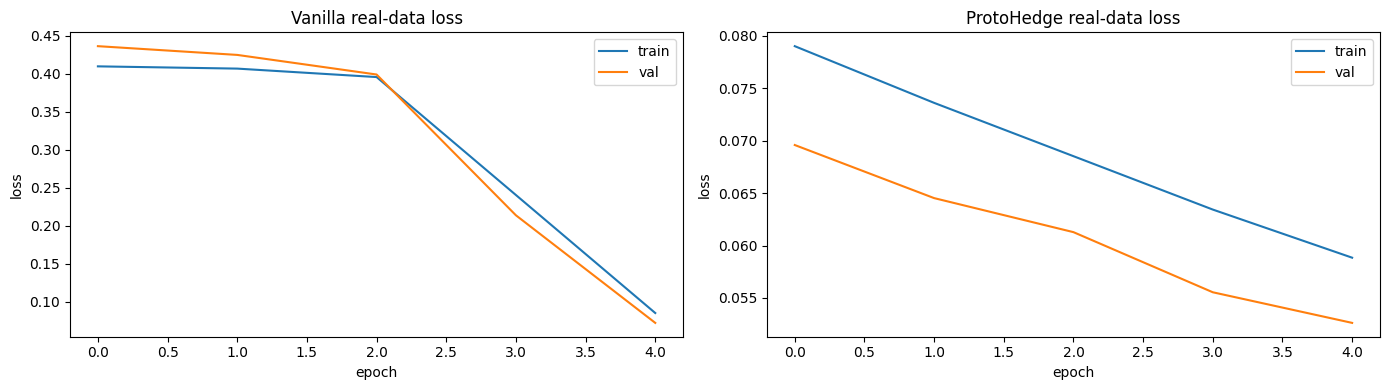

In [151]:
def plot_history(ax, history, title):
    losses = history["losses"]
    ax.plot(losses["training"], label="train")
    ax.plot(losses["val"], label="val")
    ax.set_title(title)
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_history(axes[0], results_real_vanilla["history"], "Vanilla real-data loss")
plot_history(axes[1], results_real_proto["history"], "ProtoHedge real-data loss")
plt.tight_layout()
plt.show()

## 11. Holdout Performance Plots

The core comparison is unhedged payoff vs vanilla gains vs ProtoHedge gains on held-out paths.

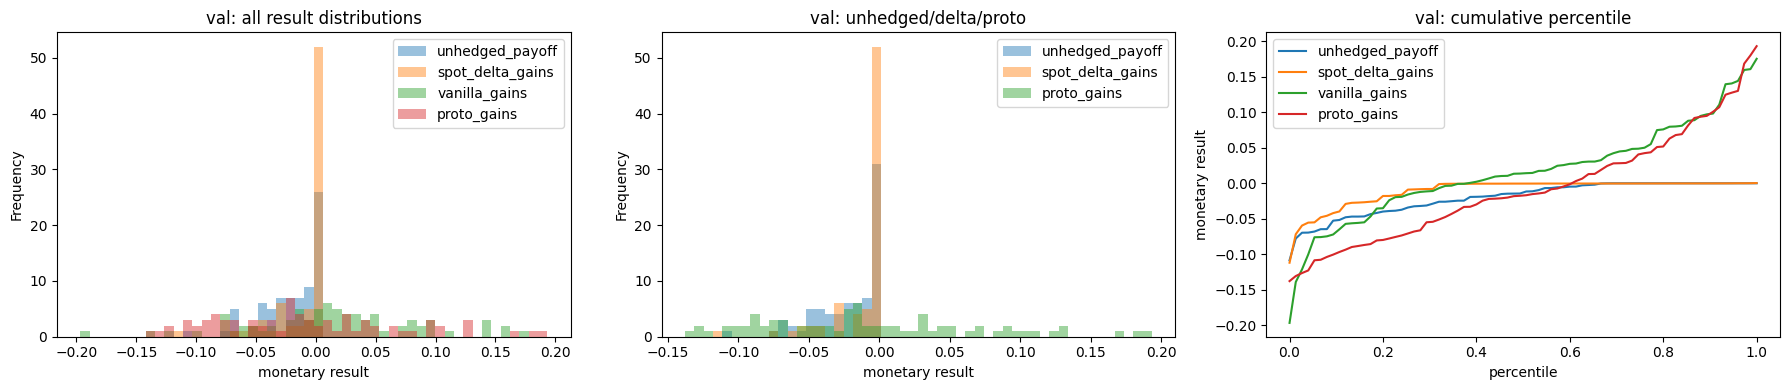

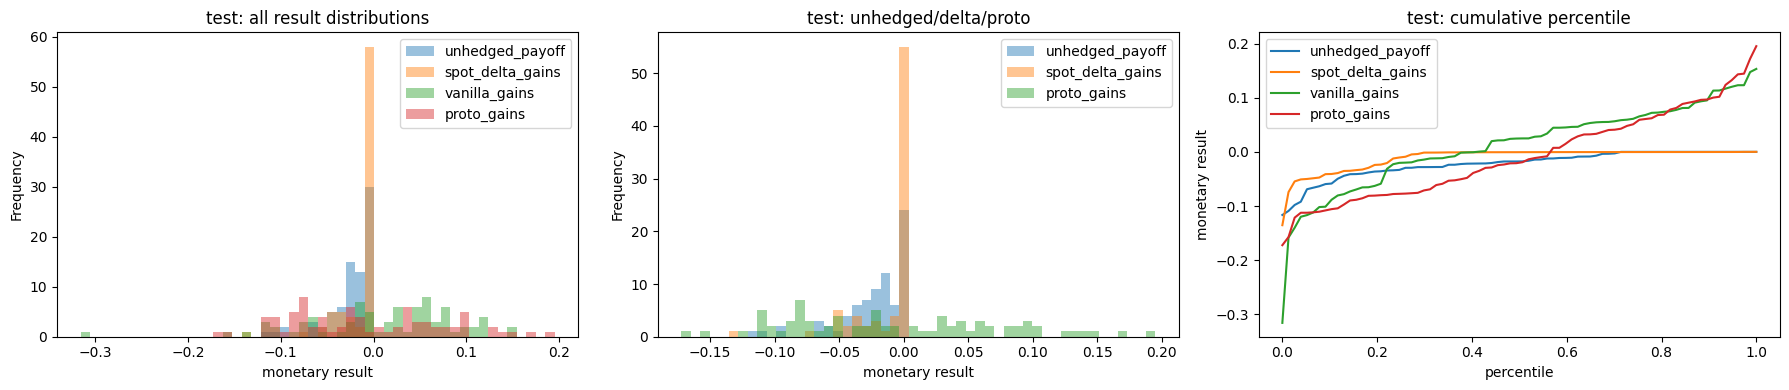

In [152]:
def split_gains_frame(split_name="test"):
    frame = pd.DataFrame()
    for model_name in ["unhedged", "spot_delta", "vanilla", "proto"]:
        result = eval_artifacts[model_name][split_name]["result"]
        label = "unhedged_payoff" if model_name == "unhedged" else f"{model_name}_gains"
        frame[label] = as_numpy(result["gains"]).reshape(-1)
    return frame

for split_name in ["val", "test"]:
    gdf = split_gains_frame(split_name)
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    # All models together.
    gdf.plot(kind="hist", bins=50, alpha=0.45, ax=axes[0])
    axes[0].set_title(f"{split_name}: all result distributions")
    axes[0].set_xlabel("monetary result")

    # Exclude vanilla if it dominates scale; this keeps ProtoHedge visible.
    non_vanilla_cols = [c for c in gdf.columns if c != "vanilla_gains"]
    gdf[non_vanilla_cols].plot(kind="hist", bins=50, alpha=0.45, ax=axes[1])
    axes[1].set_title(f"{split_name}: unhedged/delta/proto")
    axes[1].set_xlabel("monetary result")

    for col in gdf.columns:
        x = np.sort(gdf[col].values)
        y = np.linspace(0, 1, len(x))
        axes[2].plot(y, x, label=col)
    axes[2].set_title(f"{split_name}: cumulative percentile")
    axes[2].set_xlabel("percentile")
    axes[2].set_ylabel("monetary result")
    axes[2].legend()
    plt.tight_layout()
    plt.show()

In [153]:
def tail_table(split_name="test", alpha=0.05):
    gdf = split_gains_frame(split_name)
    rows = []
    for col in gdf.columns:
        x = gdf[col].values
        var = np.quantile(x, alpha)
        cvar = x[x <= var].mean() if np.any(x <= var) else var
        rows.append({
            "series": col,
            "mean": x.mean(),
            "std": x.std(),
            f"VaR_{alpha:.0%}": var,
            f"CVaR_{alpha:.0%}": cvar,
            "median": np.median(x),
        })
    return pd.DataFrame(rows)

display(tail_table("test", alpha=0.05))

,series,mean,std,VaR_5%,CVaR_5%,median
0,unhedged_payoff,-0.022705,0.026112,-0.072427,-0.103893,-0.017628
1,spot_delta_gains,-0.011322,0.022329,-0.050152,-0.078742,-0.000575
2,vanilla_gains,0.011958,0.079611,-0.117204,-0.183436,0.024712
3,proto_gains,-0.006894,0.082166,-0.112359,-0.140835,-0.020029


## 12. Prototype Table And Actions

The prototype vectors are stored in standardized feature space. We invert the scaler here so the table is interpretable.

Because `MODEL_FEATURES` is sorted internally, the 5 real-data prototype columns are:

`delta_spot`, `delta_ATM_call`, `price_spot`, `price_ATM_call`, `time_left`.

In [154]:
proto_scaled = np.asarray(prototype_payload["prototypes"])
proto_raw = prototype_payload["scaler"].inverse_transform(proto_scaled)
proto_actions = results_real_proto["model"].prototype_actions.detach().cpu().numpy()

proto_columns = ["delta_spot", "delta_ATM_call", "price_spot", "price_ATM_call", "time_left"]
action_columns = ["action_spot", "action_ATM_call"]

prototype_df = pd.DataFrame(proto_raw, columns=proto_columns)
prototype_df.insert(0, "prototype", np.arange(len(prototype_df)))
for j, col in enumerate(action_columns):
    prototype_df[col] = proto_actions[:, j]
prototype_df["action_norm"] = np.linalg.norm(proto_actions, axis=1)

display(prototype_df.sort_values("action_norm", ascending=False).head(15))
prototype_df.to_csv(OUTPUT_DIR / "prototype_table.csv", index=False)
print("saved:", OUTPUT_DIR / "prototype_table.csv")

,prototype,delta_spot,delta_ATM_call,price_spot,price_ATM_call,time_left,action_spot,action_ATM_call,action_norm
10,10,1.394089,0.011851,1.005706,0.241353,0.34,0.139831,0.006287,0.139972
19,19,2.000000,0.052633,1.043780,0.234039,0.18,0.080657,-0.105007,0.132409
15,15,2.000000,0.071627,0.972950,0.180949,0.16,-0.065458,0.111252,0.129081
21,21,2.000000,0.099718,1.015352,0.165631,0.12,0.118614,0.042950,0.126150
3,3,2.000000,0.138652,1.014785,0.547899,0.08,0.092685,0.070007,0.116153
0,0,2.000000,0.061172,1.006695,0.206878,0.20,0.110115,0.025961,0.113134
14,14,2.000000,0.041924,0.927609,0.455407,0.24,0.031015,-0.096269,0.101141
1,1,0.465071,0.003850,1.000972,0.643396,0.38,0.096391,0.012638,0.097216
13,13,2.000000,0.052553,1.009067,0.831195,0.18,0.018214,-0.091927,0.093714
7,7,2.000000,0.111302,1.055348,0.260689,0.06,-0.055202,0.072173,0.090863


saved: /Users/yaniszaim/deephedging/.deephedging_real_runs/notebook_real_data_pilot/prototype_table.csv


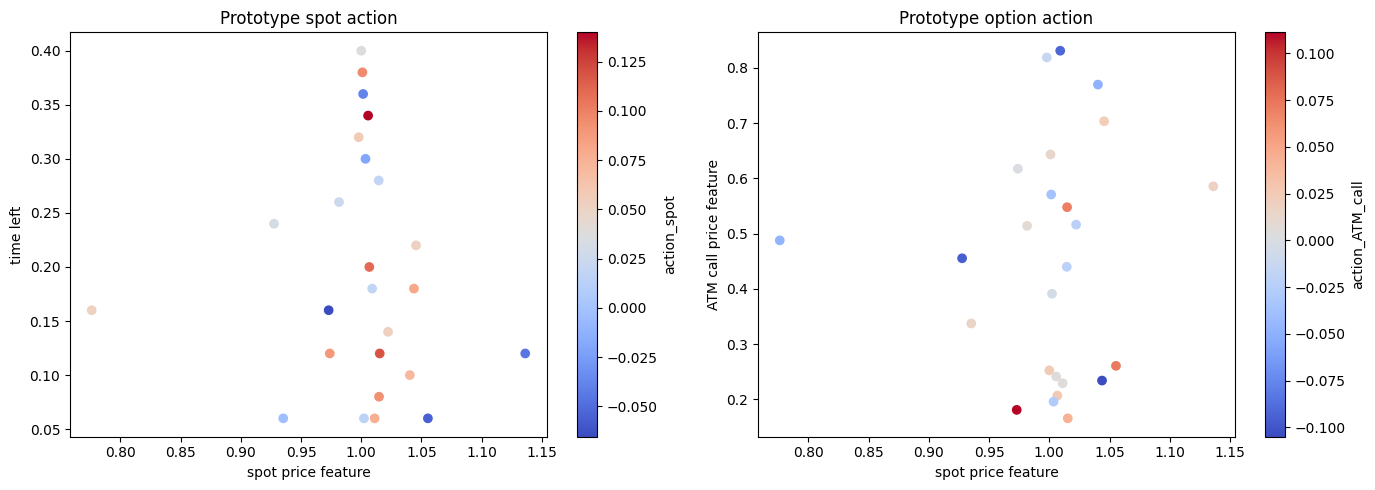

In [155]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc0 = axes[0].scatter(
    prototype_df["price_spot"],
    prototype_df["time_left"],
    c=prototype_df["action_spot"],
    cmap="coolwarm",
)
axes[0].set_title("Prototype spot action")
axes[0].set_xlabel("spot price feature")
axes[0].set_ylabel("time left")
plt.colorbar(sc0, ax=axes[0], label="action_spot")

sc1 = axes[1].scatter(
    prototype_df["price_spot"],
    prototype_df["price_ATM_call"],
    c=prototype_df["action_ATM_call"],
    cmap="coolwarm",
)
axes[1].set_title("Prototype option action")
axes[1].set_xlabel("spot price feature")
axes[1].set_ylabel("ATM call price feature")
plt.colorbar(sc1, ax=axes[1], label="action_ATM_call")
plt.tight_layout()
plt.show()

## 13. Prototype Usage On Held-Out Test Paths

If the model is interpretable, prototype usage should not be random noise. The top-used prototypes should map to sensible states and actions.

In [156]:
proto_test_result = eval_artifacts["proto"]["test"]["result"]
weights = as_numpy(proto_test_result.get("prototype_weights"))
assert weights is not None, "Expected prototype_weights from return_paths=True"

# weights shape: [paths, steps, prototypes]
avg_usage = weights.mean(axis=(0, 1))
time_usage = weights.mean(axis=0)

usage_df = pd.DataFrame({
    "prototype": np.arange(len(avg_usage)),
    "avg_usage": avg_usage,
}).merge(prototype_df, on="prototype")

display(usage_df.sort_values("avg_usage", ascending=False).head(15))
usage_df.to_csv(OUTPUT_DIR / "prototype_usage_test.csv", index=False)
print("saved:", OUTPUT_DIR / "prototype_usage_test.csv")

,prototype,avg_usage,delta_spot,delta_ATM_call,price_spot,price_ATM_call,time_left,action_spot,action_ATM_call,action_norm
22,22,0.263389,2.000000e+00,1.569504e-01,1.011099,0.229171,0.06,0.076791,0.004784,0.076940
8,8,0.203303,2.000000e+00,1.277077e-01,0.935227,0.337344,0.06,-0.003683,0.015339,0.015775
7,7,0.098949,2.000000e+00,1.113017e-01,1.055348,0.260689,0.06,-0.055202,0.072173,0.090863
4,4,0.095032,2.000000e+00,1.080375e-01,1.002253,0.391181,0.06,0.014364,-0.004742,0.015127
6,6,0.067537,3.355259e-08,3.038505e-10,1.000000,0.252547,0.40,0.035758,0.024697,0.043458
21,21,0.059305,2.000000e+00,9.971765e-02,1.015352,0.165631,0.12,0.118614,0.042950,0.126150
3,3,0.049265,2.000000e+00,1.386518e-01,1.014785,0.547899,0.08,0.092685,0.070007,0.116153
15,15,0.023043,2.000000e+00,7.162735e-02,0.972950,0.180949,0.16,-0.065458,0.111252,0.129081
24,24,0.018935,2.000000e+00,9.402062e-02,0.973902,0.617511,0.12,0.087955,0.000126,0.087955
10,10,0.016071,1.394089e+00,1.185139e-02,1.005706,0.241353,0.34,0.139831,0.006287,0.139972


saved: /Users/yaniszaim/deephedging/.deephedging_real_runs/notebook_real_data_pilot/prototype_usage_test.csv


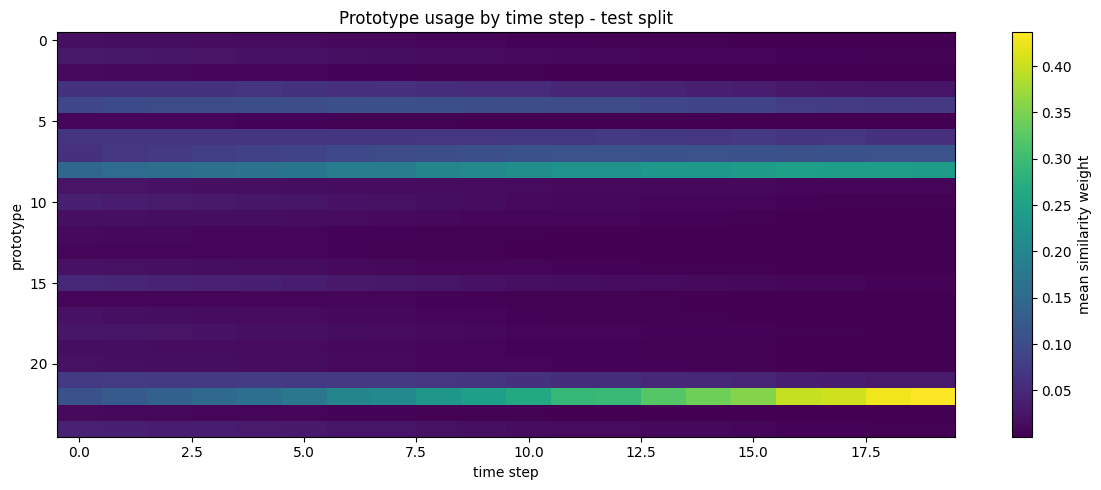

In [157]:
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(time_usage.T, aspect="auto", interpolation="nearest", cmap="viridis")
ax.set_title("Prototype usage by time step - test split")
ax.set_xlabel("time step")
ax.set_ylabel("prototype")
plt.colorbar(im, ax=ax, label="mean similarity weight")
plt.tight_layout()
plt.show()

## 14. Regime Analysis

This is a first version of the paper's robustness request. We bucket test episodes by terminal spot return and average implied volatility, then compare gains within each regime.

Later, if the raw WRDS dates are preserved in the episode metadata, we should replace these rough buckets with calendar regimes such as COVID crash, high-rate periods, earnings weeks, flash-crash windows, etc.

In [158]:
def test_regime_frame():
    world = eval_artifacts["proto"]["test"]["world"]
    spot = np.asarray(world.data.features.per_step["spot"])
    ivol = np.asarray(world.data.features.per_step["ivol"])
    terminal_return = spot[:, -1] / spot[:, 0] - 1.0
    avg_ivol = ivol.mean(axis=1)

    frame = split_gains_frame("test")
    frame["terminal_return"] = terminal_return
    frame["avg_ivol"] = avg_ivol
    frame["return_regime"] = pd.qcut(
        frame["terminal_return"],
        q=3,
        labels=["down", "middle", "up"],
        duplicates="drop",
    )
    frame["vol_regime"] = pd.qcut(
        frame["avg_ivol"],
        q=3,
        labels=["low_vol", "mid_vol", "high_vol"],
        duplicates="drop",
    )
    return frame

regime_df = test_regime_frame()
display(regime_df.head())

,unhedged_payoff,spot_delta_gains,vanilla_gains,proto_gains,terminal_return,avg_ivol,return_regime,vol_regime
0,-0.029367,-0.000229,0.065589,0.036856,0.029367,0.683026,up,mid_vol
1,-0.000000,-0.024085,0.054553,0.101740,-0.025369,0.675772,down,mid_vol
2,-0.000000,-0.135363,-0.315685,-0.076330,-0.136896,0.619289,down,low_vol
3,-0.041214,-0.000444,0.019813,-0.075630,0.041214,0.367617,up,low_vol
4,-0.007030,-0.000410,0.001341,0.007421,0.007030,0.465050,middle,low_vol


In [159]:
def summarize_by_regime(frame, regime_col):
    result_cols = [c for c in frame.columns if c.endswith("_gains") or c == "unhedged_payoff"]
    rows = []
    for regime, grp in frame.groupby(regime_col, observed=True):
        for col in result_cols:
            x = grp[col].values
            rows.append({
                "regime_type": regime_col,
                "regime": regime,
                "series": col,
                "n": len(x),
                "mean": x.mean(),
                "p05": np.quantile(x, 0.05),
                "median": np.median(x),
                "p95": np.quantile(x, 0.95),
            })
    return pd.DataFrame(rows)

return_regime_summary = summarize_by_regime(regime_df, "return_regime")
vol_regime_summary = summarize_by_regime(regime_df, "vol_regime")
regime_summary = pd.concat([return_regime_summary, vol_regime_summary], ignore_index=True)
regime_summary.to_csv(OUTPUT_DIR / "regime_summary_test.csv", index=False)
display(regime_summary)
print("saved:", OUTPUT_DIR / "regime_summary_test.csv")

,regime_type,regime,series,n,mean,p05,median,p95
0,return_regime,down,unhedged_payoff,26,-0.000382,-0.003314,0.000000,-0.000000
1,return_regime,down,spot_delta_gains,26,-0.032565,-0.069321,-0.033157,-0.000335
2,return_regime,down,vanilla_gains,26,-0.053242,-0.153682,-0.067363,0.074974
3,return_regime,down,proto_gains,26,-0.004987,-0.103072,-0.022119,0.118161
4,return_regime,middle,unhedged_payoff,26,-0.016529,-0.023781,-0.017628,-0.008599
5,return_regime,middle,spot_delta_gains,26,-0.000437,-0.001094,-0.000383,-0.000002
6,return_regime,middle,vanilla_gains,26,0.031035,-0.022159,0.029307,0.116061
7,return_regime,middle,proto_gains,26,-0.002647,-0.111882,-0.010972,0.162056
8,return_regime,up,unhedged_payoff,26,-0.051204,-0.106279,-0.040594,-0.028088
9,return_regime,up,spot_delta_gains,26,-0.000965,-0.001230,-0.000431,-0.000231


saved: /Users/yaniszaim/deephedging/.deephedging_real_runs/notebook_real_data_pilot/regime_summary_test.csv


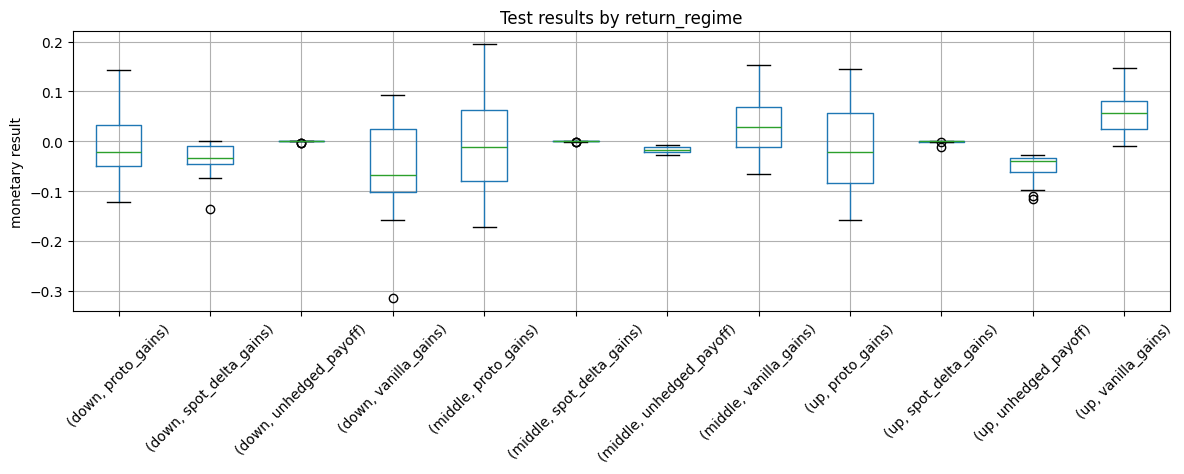

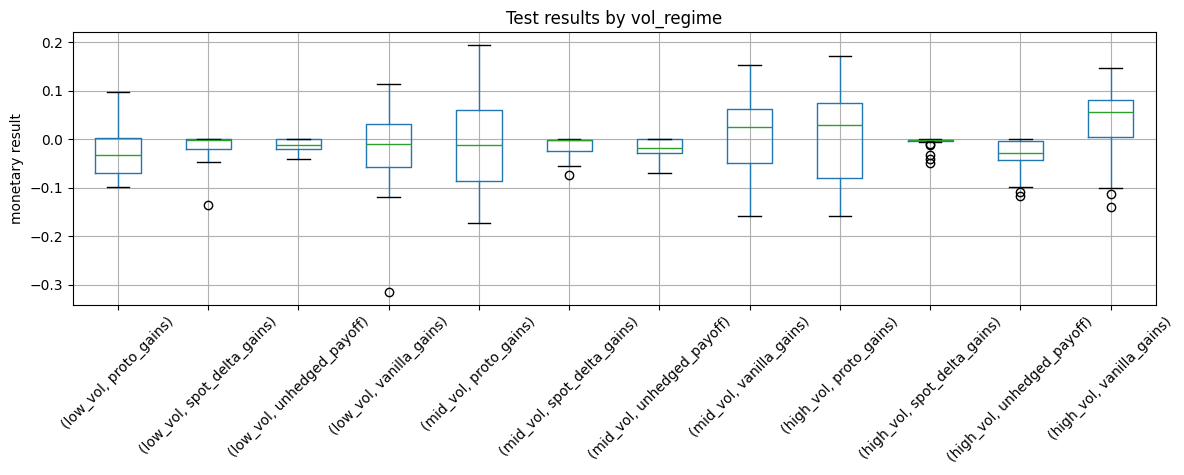

In [160]:
for regime_col in ["return_regime", "vol_regime"]:
    fig, ax = plt.subplots(figsize=(12, 5))
    result_cols = [c for c in regime_df.columns if c.endswith("_gains") or c == "unhedged_payoff"]
    plot_df = regime_df.melt(
        id_vars=[regime_col],
        value_vars=result_cols,
        var_name="series",
        value_name="result",
    )
    plot_df.boxplot(column="result", by=[regime_col, "series"], ax=ax, rot=45)
    ax.set_title(f"Test results by {regime_col}")
    ax.set_xlabel("")
    ax.set_ylabel("monetary result")
    plt.suptitle("")
    plt.tight_layout()
    plt.show()

## 15. Current Baselines And Next Baselines

This notebook now compares:

- `unhedged_payoff`: no hedge.
- `spot_delta_gains`: a simple empirical spot-delta hedge using the dataset's `call_delta` feature.
- `vanilla_gains`: vanilla neural Deep Hedging.
- `proto_gains`: prototype-based Deep Hedging.

The spot-delta baseline is intentionally simple and transparent. It does not use the option hedge instrument yet; it only targets a spot position near the empirical call delta for a short call. That makes it a useful sanity baseline before adding richer classical baselines.

A later extension should add:

- a spot-plus-option delta/vega hedge,
- transaction-cost-aware delta rebalancing bands,
- buy-and-hold option hedge baselines,
- walk-forward retraining instead of one random split.

## 16. Decision Gate Before Larger Real-Data Experiments

Use this checklist after each run:

- Did both neural models train without NaNs?
- Did validation/test metrics remain finite?
- Are we now using the original real-data semantics, i.e. `HEDGE_MODE = "step"`?
- Are normalized payoff/gains on a plausible scale, roughly comparable to synthetic-world magnitudes?
- Are cumulative positions inside the configured bounds?
- Is vanilla no longer producing obviously leveraged, economically impossible gains?
- Does ProtoHedge improve over unhedged on test tail metrics?
- Is ProtoHedge competitive with vanilla Deep Hedging and the spot-delta baseline on test utility/downside risk?
- Are prototype actions within plausible ranges, not all saturated at bounds?
- Do the new bound-saturation diagnostics show reasonable occupancy rather than a strategy living on the rails?
- Are top-used prototypes interpretable in raw feature space?
- Does performance remain reasonable in down-market and high-volatility regimes?
- Are results stable if you rerun with a different seed or prototype count?

If the answer is yes, then we are ready to scale this notebook to more paths, longer training, more prototype counts, and eventually more tickers/markets/options.

## 17. Suggested Next Runs

The smoke run and source-sensitivity work are now complete enough to move to original-style full training under the correct real-data semantics. Keep the earlier single-model cells as quick diagnostics; use the sweep section below for the serious runs so every model is trained and evaluated under the same split, bounds, prototype source, and reporting logic.

The next run should be the focused original-epoch step sweep:

- all available real-data paths,
- one-step hedge increments, matching the original TensorFlow `world_real.py`,
- 800 epochs, matching the original ProtoHedge training scale,
- one seed first,
- prototype counts `[10, 25, 50, 100]`,
- the two most relevant prototype sources: `spot_delta` and `vanilla`,
- weighted and unweighted prototype similarity.

If that stays positive, the paper-level follow-up is the same grid across multiple seeds. Only after that should we spend time on broader tickers, markets, and option types.

## 18. Automated Interpretation Diagnostics

This section turns the tables above into explicit diagnostics. It checks three things that matter for the empirical ProtoHedge story:

- **Performance:** mean, downside tail, and utility relative to unhedged, spot-delta, and vanilla.
- **Constraint behavior:** whether a model is trading by saturating the cumulative position bounds.
- **Prototype behavior:** whether usage is concentrated and whether ProtoHedge actions are too small.

These diagnostics are not replacements for judgment, but they make the next experiment less vibes-based.

In [161]:
def make_test_comparison(metrics_df, split="test"):
    df = metrics_df[metrics_df["split"] == split].copy()
    cols = [
        "model", "gains_mean", "gains_p05", "gains_p50", "pnl_mean", "cost_mean",
        "action_abs_mean", "action_abs_max", "delta_abs_mean", "delta_abs_max", "utility_mean",
    ]
    cols = [c for c in cols if c in df.columns]
    out = df[cols].sort_values("gains_mean", ascending=False).reset_index(drop=True)

    base = df.set_index("model")
    if "proto" in base.index:
        proto_mean = base.loc["proto", "gains_mean"]
        proto_p05 = base.loc["proto", "gains_p05"]
        for model_name in ["unhedged", "spot_delta", "vanilla"]:
            if model_name in base.index:
                out[f"proto_mean_minus_{model_name}"] = proto_mean - base.loc[model_name, "gains_mean"]
                out[f"proto_p05_minus_{model_name}"] = proto_p05 - base.loc[model_name, "gains_p05"]
    return out

comparison_test = make_test_comparison(metrics_df, "test")
display(comparison_test)

,model,gains_mean,gains_p05,gains_p50,pnl_mean,cost_mean,action_abs_mean,action_abs_max,delta_abs_mean,delta_abs_max,utility_mean,proto_mean_minus_unhedged,proto_p05_minus_unhedged,proto_mean_minus_spot_delta,proto_p05_minus_spot_delta,proto_mean_minus_vanilla,proto_p05_minus_vanilla
0,vanilla,0.011958,-0.117204,0.024712,0.035157,0.000495,0.054946,0.466304,0.965020,2.000000,-0.048665,0.015811,-0.039931,0.004428,-0.062207,-0.018851,0.004845
1,proto,-0.006894,-0.112359,-0.020029,0.016134,0.000323,0.027217,0.044429,0.285225,0.795465,-0.077940,0.015811,-0.039931,0.004428,-0.062207,-0.018851,0.004845
2,spot_delta,-0.011322,-0.050152,-0.000575,0.011609,0.000227,0.028340,0.999861,0.495822,0.999988,NaN,0.015811,-0.039931,0.004428,-0.062207,-0.018851,0.004845
3,unhedged,-0.022705,-0.072427,-0.017628,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.015811,-0.039931,0.004428,-0.062207,-0.018851,0.004845


In [162]:
def position_saturation_table(split_name="test", tol=1e-4):
    rows = []
    for model_name in ["spot_delta", "vanilla", "proto"]:
        if model_name not in eval_artifacts or split_name not in eval_artifacts[model_name]:
            continue
        world = eval_artifacts[model_name][split_name]["world"]
        result = eval_artifacts[model_name][split_name]["result"]
        if "deltas" not in result:
            continue
        deltas = as_numpy(result["deltas"])
        if "ubnd_delta" in world.data.market and "lbnd_delta" in world.data.market:
            ub = np.asarray(world.data.market.ubnd_delta)
            lb = np.asarray(world.data.market.lbnd_delta)
            near_upper = np.isclose(deltas, ub, atol=tol, rtol=0.0)
            near_lower = np.isclose(deltas, lb, atol=tol, rtol=0.0)
            near_bound = near_upper | near_lower
        else:
            near_upper = near_lower = near_bound = np.zeros_like(deltas, dtype=bool)

        rows.append({
            "model": model_name,
            "split": split_name,
            "delta_abs_mean": float(np.mean(np.abs(deltas))),
            "delta_abs_max": float(np.max(np.abs(deltas))),
            "pct_at_any_position_bound": float(np.mean(near_bound)),
            "pct_at_upper_position_bound": float(np.mean(near_upper)),
            "pct_at_lower_position_bound": float(np.mean(near_lower)),
        })
    return pd.DataFrame(rows)

saturation_test = position_saturation_table("test")
display(saturation_test)
saturation_test.to_csv(OUTPUT_DIR / "position_saturation_test.csv", index=False)
print("saved:", OUTPUT_DIR / "position_saturation_test.csv")

,model,split,delta_abs_mean,delta_abs_max,pct_at_any_position_bound,pct_at_upper_position_bound,pct_at_lower_position_bound
0,spot_delta,test,0.495822,0.999988,0.0,0.0,0.0
1,vanilla,test,0.965020,2.000000,0.4,0.4,0.0
2,proto,test,0.285225,0.795465,0.0,0.0,0.0


saved: /Users/yaniszaim/deephedging/.deephedging_real_runs/notebook_real_data_pilot/position_saturation_test.csv


In [163]:
def prototype_usage_diagnostics(usage_df):
    usage = usage_df["avg_usage"].to_numpy(dtype=float)
    usage = usage / max(usage.sum(), 1e-12)
    entropy = -np.sum(np.where(usage > 0, usage * np.log(usage), 0.0))
    effective_n = float(np.exp(entropy))
    top = np.sort(usage)[::-1]
    return pd.DataFrame([{
        "n_prototypes": len(usage),
        "top1_usage": float(top[:1].sum()),
        "top3_usage": float(top[:3].sum()),
        "top5_usage": float(top[:5].sum()),
        "entropy": float(entropy),
        "effective_n_prototypes": effective_n,
        "action_norm_mean": float(usage_df["action_norm"].mean()),
        "action_norm_max": float(usage_df["action_norm"].max()),
    }])

usage_diagnostics = prototype_usage_diagnostics(usage_df)
display(usage_diagnostics)
usage_diagnostics.to_csv(OUTPUT_DIR / "prototype_usage_diagnostics.csv", index=False)
print("saved:", OUTPUT_DIR / "prototype_usage_diagnostics.csv")

,n_prototypes,top1_usage,top3_usage,top5_usage,entropy,effective_n_prototypes,action_norm_mean,action_norm_max
0,25,0.263389,0.565641,0.72821,2.362061,10.612798,0.075971,0.139972


saved: /Users/yaniszaim/deephedging/.deephedging_real_runs/notebook_real_data_pilot/prototype_usage_diagnostics.csv


In [164]:
def print_real_data_interpretation(metrics_df):
    test = metrics_df[metrics_df["split"] == "test"].set_index("model")
    lines = []
    lines.append("Current normalized/bounded real-data interpretation:")
    if {"unhedged", "spot_delta", "vanilla", "proto"}.issubset(test.index):
        proto_mean = test.loc["proto", "gains_mean"]
        proto_tail = test.loc["proto", "gains_p05"]
        lines.append(f"- Proto mean gains: {proto_mean:.6f}")
        lines.append(f"- Proto 5% gains tail: {proto_tail:.6f}")
        lines.append(f"- Proto minus unhedged mean: {proto_mean - test.loc['unhedged', 'gains_mean']:.6f}")
        lines.append(f"- Proto minus spot-delta mean: {proto_mean - test.loc['spot_delta', 'gains_mean']:.6f}")
        lines.append(f"- Proto minus vanilla mean: {proto_mean - test.loc['vanilla', 'gains_mean']:.6f}")
        lines.append(f"- Proto 5% tail minus unhedged: {proto_tail - test.loc['unhedged', 'gains_p05']:.6f}")
        lines.append(f"- Proto 5% tail minus spot-delta: {proto_tail - test.loc['spot_delta', 'gains_p05']:.6f}")
        lines.append(f"- Proto 5% tail minus vanilla: {proto_tail - test.loc['vanilla', 'gains_p05']:.6f}")
        if "delta_abs_max" in test.columns:
            lines.append(f"- Vanilla max absolute position: {test.loc['vanilla', 'delta_abs_max']:.6f}")
            lines.append(f"- Proto max absolute position: {test.loc['proto', 'delta_abs_max']:.6f}")
    print("\n".join(lines))

print_real_data_interpretation(metrics_df)

Current normalized/bounded real-data interpretation:
- Proto mean gains: -0.006894
- Proto 5% gains tail: -0.112359
- Proto minus unhedged mean: 0.015811
- Proto minus spot-delta mean: 0.004428
- Proto minus vanilla mean: -0.018851
- Proto 5% tail minus unhedged: -0.039931
- Proto 5% tail minus spot-delta: -0.062207
- Proto 5% tail minus vanilla: 0.004845
- Vanilla max absolute position: 2.000000
- Proto max absolute position: 0.795465


## 19. Prototype Source Sensitivity

The current ProtoHedge payload is extracted from the vanilla model's training trajectories. That is faithful to the current workflow, but the diagnostics show many train states have `delta_spot` near the cumulative position bound. That can make the prototype space reflect a saturated vanilla policy rather than a broad set of empirical market states.

This optional section tests whether ProtoHedge improves when prototypes are extracted from different state distributions:

- `vanilla_source`: current/default behavior.
- `spot_delta_source`: prototype states from the transparent empirical spot-delta hedge.
- `zero_market_source`: market states with zero pre-existing hedge position.

Leave `RUN_PROTO_SOURCE_SENSITIVITY = False` for ordinary notebook runs. Turn it on when you want the next experiment.

In [165]:
RUN_PROTO_SOURCE_SENSITIVITY = False
PROTO_SOURCE_VARIANTS = ["spot_delta_source", "zero_market_source"]
PROTO_SOURCE_EPOCHS = EPOCHS
PROTO_SOURCE_N_PROTOTYPES = N_PROTOTYPES


def train_and_evaluate_proto_variant(variant_name, source_result, n_prototypes=PROTO_SOURCE_N_PROTOTYPES, epochs=PROTO_SOURCE_EPOCHS):
    variant_dir = OUTPUT_DIR / "proto_source_sensitivity"
    variant_dir.mkdir(parents=True, exist_ok=True)
    variant_path = variant_dir / f"{variant_name}_prototypes_{n_prototypes}.pkl"

    payload = build_prototype_payload(
        world=results_real_vanilla["world"],
        result=source_result,
        n_prototypes=n_prototypes,
        feature_names=MODEL_FEATURES,
        random_state=SEED,
        max_points=MAX_POINTS,
    )
    save_prototype_payload(payload, variant_path)

    result = run_experiment(
        override_world=world_cfg(splits["train"], val_indices=splits["val"]),
        override_model=proto_model_cfg(variant_path),
        override_objective=objective_cfg(),
        override_training=training_cfg(epochs),
    )

    artifacts = {}
    variant_metrics = {}
    for split_name, idx in splits.items():
        w, r, m = evaluate_gym(result["gym"], idx, f"{variant_name} {split_name}")
        artifacts[split_name] = {"world": w, "result": r}
        variant_metrics[split_name] = m

    proto_raw = payload["scaler"].inverse_transform(np.asarray(payload["prototypes"]))
    proto_actions = result["model"].prototype_actions.detach().cpu().numpy()
    proto_df = pd.DataFrame(proto_raw, columns=proto_columns)
    proto_df.insert(0, "prototype", np.arange(len(proto_df)))
    for j, col in enumerate(action_columns):
        proto_df[col] = proto_actions[:, j]
    proto_df["action_norm"] = np.linalg.norm(proto_actions, axis=1)
    proto_df.to_csv(variant_dir / f"{variant_name}_prototype_table.csv", index=False)

    return {
        "name": variant_name,
        "prototype_path": variant_path,
        "payload": payload,
        "training": result,
        "artifacts": artifacts,
        "metrics": variant_metrics,
        "prototype_table": proto_df,
    }


def run_proto_source_sensitivity():
    source_results = {
        "spot_delta_source": eval_artifacts["spot_delta"]["train"]["result"],
        "zero_market_source": None,
    }
    variant_results = {}
    variant_metric_rows = []

    for variant_name in PROTO_SOURCE_VARIANTS:
        print(f"\n=== Running {variant_name} ===")
        variant = train_and_evaluate_proto_variant(
            variant_name=variant_name,
            source_result=source_results[variant_name],
            n_prototypes=PROTO_SOURCE_N_PROTOTYPES,
            epochs=PROTO_SOURCE_EPOCHS,
        )
        variant_results[variant_name] = variant
        for split_name, values in variant["metrics"].items():
            row = {"model": variant_name, "split": split_name}
            row.update({k: v for k, v in values.items() if not isinstance(v, list)})
            variant_metric_rows.append(row)

    variant_metrics_df = pd.DataFrame(variant_metric_rows)
    variant_metrics_df.to_csv(OUTPUT_DIR / "proto_source_sensitivity_metrics.csv", index=False)
    print("saved:", OUTPUT_DIR / "proto_source_sensitivity_metrics.csv")
    return variant_results, variant_metrics_df

if RUN_PROTO_SOURCE_SENSITIVITY:
    proto_source_results, proto_source_metrics_df = run_proto_source_sensitivity()
    display(proto_source_metrics_df[proto_source_metrics_df["split"] == "test"].sort_values("gains_mean", ascending=False))
else:
    print("Prototype source sensitivity is ready. Set RUN_PROTO_SOURCE_SENSITIVITY = True and rerun this cell when you want the next experiment.")

Prototype source sensitivity is ready. Set RUN_PROTO_SOURCE_SENSITIVITY = True and rerun this cell when you want the next experiment.


## 20. Recommended Experiment Queue

Based on the current normalized/bounded run, the pipeline works and the remaining question is empirical competitiveness: can ProtoHedge's prototype bottleneck match or beat vanilla Deep Hedging and simple baselines on held-out historical paths under the original real-data hedge accounting?

Run the queue in this order:

1. Use `focused_original_epochs` in the sweep section below: full data, step-mode hedge increments, 800 epochs, one seed, prototype counts `[10, 25, 50, 100]`, sources `spot_delta` and `vanilla`.
2. Read the generated `paper_best_models.csv`, `paper_model_comparison.csv`, the new bound-saturation outputs, and the plots before launching anything larger.
3. If ProtoHedge remains competitive on mean, CVaR, shortfall probability, and bound occupancy, run `paper_original_epochs` for the same grid across three seeds.
4. If the full run shows ProtoHedge only wins by saturating bounds, tighten the real-data environment and rerun the same grid.
5. If ProtoHedge is stable across seeds, move from one dataset to multiple tickers/markets and then path-dependent options.

The paper-level claim we are moving toward is: ProtoHedge can remain competitive with strong hedging baselines on historical data while exposing a compact set of interpretable prototype states.

## 21. Real-Data Sweep: ProtoHedge vs Baselines

This is the experiment grid that corresponds to the next research question:

> Across the real-data environment, can any ProtoHedge configuration match vanilla Deep Hedging, or at least reliably beat unhedged and simple spot-delta hedging?

The grid mirrors the main ProtoHedge-style knobs we used in the synthetic notebooks:

- number of prototypes,
- weighted vs unweighted similarity,
- prototype source distribution,
- random seed/split,
- CVaR objective.

This sweep now defaults to the original TensorFlow real-data hedge accounting by using `HEDGE_MODE = "step"` from the notebook config above.

The cell below uses named presets so the workflow stays clean:

- `pilot`: fast 512-path / 5-epoch check, useful after code changes.
- `focused_original_epochs`: the next real run; all paths, step mode, 800 epochs, one seed, focused grid.
- `paper_original_epochs`: stronger empirical table; all paths, step mode, 800 epochs, three seeds.

`Run All` is now configured to launch the focused step-mode sweep automatically. The helper checkpoints metrics, paper tables, plots, and config after every completed model so an interrupted long run still leaves usable artifacts behind.

In [166]:
import importlib
import deephedging.real_data_sweep_torch as real_data_sweep_torch
real_data_sweep_torch = importlib.reload(real_data_sweep_torch)

RUN_REAL_DATA_SWEEP = True
SWEEP_PRESET = "focused_original_epochs"  # "pilot", "focused_original_epochs", or "paper_original_epochs"
FULL_RUN_EPOCHS = 800
FULL_RUN_EPOCH_REFRESH = 50

SWEEP_PRESETS = {
    "pilot": {
        "output_dir": REPO_ROOT / ".deephedging_real_runs" / "real_data_sweep_step",
        "samples": 512,
        "epochs": 5,
        "epoch_refresh": 5,
        "seeds": [1234],
        "prototype_counts": [10, 25, 50],
        "prototype_sources": ["vanilla", "spot_delta", "zero"],
        "weighted_options": [True, False],
        "learn_weight_options": [False],
        "risk_measures": ["cvar"],
        "max_points": MAX_POINTS,
    },
    "focused_original_epochs": {
        "output_dir": REPO_ROOT / ".deephedging_real_runs" / "real_data_sweep_focused_800_step",
        "samples": None,
        "epochs": FULL_RUN_EPOCHS,
        "epoch_refresh": FULL_RUN_EPOCH_REFRESH,
        "seeds": [1234],
        "prototype_counts": [10, 25, 50, 100],
        "prototype_sources": ["spot_delta", "vanilla"],
        "weighted_options": [True, False],
        "learn_weight_options": [False],
        "risk_measures": ["cvar"],
        "max_points": MAX_POINTS,
    },
    "paper_original_epochs": {
        "output_dir": REPO_ROOT / ".deephedging_real_runs" / "real_data_sweep_paper_800_step",
        "samples": None,
        "epochs": FULL_RUN_EPOCHS,
        "epoch_refresh": FULL_RUN_EPOCH_REFRESH,
        "seeds": [1234, 2345, 3456],
        "prototype_counts": [10, 25, 50, 100],
        "prototype_sources": ["spot_delta", "vanilla"],
        "weighted_options": [True, False],
        "learn_weight_options": [False],
        "risk_measures": ["cvar"],
        "max_points": MAX_POINTS,
    },
}

preset = SWEEP_PRESETS[SWEEP_PRESET]
SWEEP_OUTPUT_DIR = preset["output_dir"]

n_vanilla_runs = len(preset["seeds"]) * len(preset["risk_measures"])
n_proto_runs = (
    len(preset["seeds"])
    * len(preset["risk_measures"])
    * len(preset["prototype_counts"])
    * len(preset["prototype_sources"])
    * len(preset["weighted_options"])
    * len(preset["learn_weight_options"])
)

print("sweep preset:", SWEEP_PRESET)
print("output dir:", SWEEP_OUTPUT_DIR)
print("samples:", "all paths" if preset["samples"] is None else preset["samples"])
print("epochs per neural run:", preset["epochs"])
print("epoch_refresh:", preset["epoch_refresh"])
print("hedge_mode:", HEDGE_MODE)
print("seeds:", preset["seeds"])
print("prototype_counts:", preset["prototype_counts"])
print("prototype_sources:", preset["prototype_sources"])
print("weighted_options:", preset["weighted_options"])
print("neural training jobs:", n_vanilla_runs + n_proto_runs, f"({n_vanilla_runs} vanilla + {n_proto_runs} proto)")
print("checkpointing: after baselines, vanilla, and every ProtoHedge variant")

if RUN_REAL_DATA_SWEEP:
    sweep_metrics_df = real_data_sweep_torch.run_real_data_sweep(
        data_path=DATA_PATH,
        output_dir=SWEEP_OUTPUT_DIR,
        samples=preset["samples"],
        epochs=preset["epochs"],
        seeds=preset["seeds"],
        prototype_counts=preset["prototype_counts"],
        prototype_sources=preset["prototype_sources"],
        weighted_similarity_options=preset["weighted_options"],
        learn_distance_feature_weights_options=preset["learn_weight_options"],
        risk_measures=preset["risk_measures"],
        normalize=NORMALIZE_REAL_WORLD,
        hedge_mode=HEDGE_MODE,
        position_bounds=USE_POSITION_BOUNDS,
        trade_bounds=TRADE_BOUNDS,
        cumulative_bounds=POSITION_BOUNDS,
        lr=LR,
        batch_size=BATCH_SIZE,
        epoch_refresh=preset["epoch_refresh"],
        max_points=preset["max_points"],
    )
else:
    metrics_path = SWEEP_OUTPUT_DIR / "sweep_metrics.csv"
    if metrics_path.exists():
        sweep_metrics_df = pd.read_csv(metrics_path)
        print("Loaded existing sweep metrics:", metrics_path)
    else:
        sweep_metrics_df = None
        print("Full sweep is configured but not launched. Set RUN_REAL_DATA_SWEEP = True when ready.")

sweep preset: focused_original_epochs
output dir: /Users/yaniszaim/deephedging/.deephedging_real_runs/real_data_sweep_focused_800
samples: all paths
epochs per neural run: 800
epoch_refresh: 50
seeds: [1234]
prototype_counts: [10, 25, 50, 100]
prototype_sources: ['spot_delta', 'vanilla']
weighted_options: [True, False]
neural training jobs: 17 (1 vanilla + 16 proto)
checkpointing: after baselines, vanilla, and every ProtoHedge variant

[checkpoint:seed_1234_baselines] saved 6 metric rows to /Users/yaniszaim/deephedging/.deephedging_real_runs/real_data_sweep_focused_800/sweep_metrics.csv

=== seed=1234 risk=cvar vanilla ===

PyTorch version 2.5.1 running on 8 CPUs and 0 GPUs
epoch 0 | batch 0.2734 | train 0.0758 | val 0.0687
epoch 50 | batch -2.8648 | train -2.8562 | val -2.8986
epoch 100 | batch -3.1091 | train -3.1252 | val -3.2317
epoch 150 | batch -3.1424 | train -3.1586 | val -3.2586
epoch 200 | batch -3.1591 | train -3.1667 | val -3.2752
epoch 250 | batch -3.1569 | train -3.1520 |

## 22. Sweep Dashboard And Paper Tables

After the sweep runs, this dashboard ranks models by held-out test metrics and shows the generated plot files.

Interpretation priority:

1. `gains_mean_avg`: average test result across seeds/splits.
2. `gains_cvar05_avg`: average 5% tail outcome. Higher is better because losses are less severe.
3. `shortfall_prob_avg`: fraction of paths with negative gains. Lower is better.
4. `pct_at_any_position_bound_avg`: fraction of delta states at a cumulative position bound.
5. `pct_paths_touch_any_position_bound_avg`: fraction of test paths that touch a cumulative bound at least once.
6. `delta_abs_max_avg`: a rough cap check; useful, but less informative than actual occupancy.

The generated `paper_*` files are the ones to use in writeups and presentations.

,model,model_family,prototype_source,n_prototypes,weighted_similarity,gains_mean_avg,gains_p05_avg,gains_cvar05_avg,shortfall_prob_avg,delta_abs_max_avg,action_abs_mean_avg,n_runs
0,vanilla,vanilla,NaN,NaN,NaN,5.333175,1.186211,0.486808,0.010386,2.000000,1.277493,1
1,proto_source=spot_delta_k=25_weighted=1_learnw=0,proto,spot_delta,25.0,True,5.236279,1.208732,0.503272,0.007418,2.000000,0.903523,1
2,proto_source=spot_delta_k=50_weighted=0_learnw=0,proto,spot_delta,50.0,False,5.219158,1.215826,0.662364,0.002967,2.000000,0.985185,1
3,proto_source=vanilla_k=50_weighted=1_learnw=0,proto,vanilla,50.0,True,5.206510,1.135134,0.355936,0.016320,2.000000,0.933924,1
4,proto_source=spot_delta_k=50_weighted=1_learnw=0,proto,spot_delta,50.0,True,5.201675,0.966569,0.449929,0.002967,2.000000,0.978989,1
5,proto_source=spot_delta_k=10_weighted=0_learnw=0,proto,spot_delta,10.0,False,5.185910,1.149661,0.517080,0.005935,2.000000,1.001225,1
6,proto_source=spot_delta_k=100_weighted=1_learnw=0,proto,spot_delta,100.0,True,5.184873,1.026617,0.616871,0.004451,2.000000,0.982660,1
7,proto_source=spot_delta_k=25_weighted=0_learnw=0,proto,spot_delta,25.0,False,5.158178,1.114550,0.527555,0.004451,2.000000,1.005548,1
8,proto_source=vanilla_k=50_weighted=0_learnw=0,proto,vanilla,50.0,False,5.152256,1.180254,0.350204,0.010386,2.000000,1.033043,1
9,proto_source=spot_delta_k=100_weighted=0_learnw=0,proto,spot_delta,100.0,False,5.115752,1.032446,0.574660,0.002967,2.000000,0.929947,1


Best model selections:


,selection,model,model_family,prototype_source,n_prototypes,weighted_similarity,gains_mean_avg,gains_cvar05_avg,shortfall_prob_avg,gains_mean_avg_minus_vanilla,gains_mean_avg_minus_unhedged,gains_mean_avg_minus_spot_delta,n_runs
0,best_mean,vanilla,vanilla,NaN,NaN,NaN,5.333175,0.486808,0.010386,0.000000,5.353372,5.347865,1
1,best_cvar05,proto_source=spot_delta_k=50_weighted=0_learnw=0,proto,spot_delta,50.0,False,5.219158,0.662364,0.002967,-0.114017,5.239355,5.233848,1
2,best_shortfall,proto_source=spot_delta_k=100_weighted=0_learnw=0,proto,spot_delta,100.0,False,5.115752,0.574660,0.002967,-0.217423,5.135949,5.130442,1
3,best_proto_mean,proto_source=spot_delta_k=25_weighted=1_learnw=0,proto,spot_delta,25.0,True,5.236279,0.503272,0.007418,-0.096897,5.256476,5.250969,1
4,best_proto_cvar05,proto_source=spot_delta_k=50_weighted=0_learnw=0,proto,spot_delta,50.0,False,5.219158,0.662364,0.002967,-0.114017,5.239355,5.233848,1
5,best_proto_shortfall,proto_source=spot_delta_k=50_weighted=0_learnw=0,proto,spot_delta,50.0,False,5.219158,0.662364,0.002967,-0.114017,5.239355,5.233848,1


Paper selected comparison table:


,model,model_family,prototype_source,n_prototypes,weighted_similarity,gains_mean_avg,gains_cvar05_avg,shortfall_prob_avg,gains_mean_avg_minus_vanilla,gains_cvar05_avg_minus_vanilla,n_runs
0,vanilla,vanilla,NaN,NaN,NaN,5.333175,0.486808,0.010386,0.000000,0.000000,1
1,proto_source=spot_delta_k=25_weighted=1_learnw=0,proto,spot_delta,25.0,True,5.236279,0.503272,0.007418,-0.096897,0.016464,1
2,proto_source=spot_delta_k=50_weighted=0_learnw=0,proto,spot_delta,50.0,False,5.219158,0.662364,0.002967,-0.114017,0.175556,1
3,proto_source=spot_delta_k=100_weighted=0_learnw=0,proto,spot_delta,100.0,False,5.115752,0.574660,0.002967,-0.217423,0.087852,1
4,spot_delta,baseline,NaN,NaN,NaN,-0.014690,-0.128939,0.962908,-5.347865,-0.615747,1
5,unhedged,baseline,NaN,NaN,NaN,-0.020197,-0.092059,0.646884,-5.353372,-0.578867,1


# Real-Data ProtoHedge Sweep Interpretation

This report is generated from `sweep_metrics.csv`.

## Baselines

- `vanilla`: mean `5.333175`, CVaR5 `0.486808`, shortfall `0.010386`
- `spot_delta`: mean `-0.014690`, CVaR5 `-0.128939`, shortfall `0.962908`
- `unhedged`: mean `-0.020197`, CVaR5 `-0.092059`, shortfall `0.646884`

## Best ProtoHedge Configurations

- Best mean: `proto_source=spot_delta_k=25_weighted=1_learnw=0` with mean `5.236279` and CVaR5 `0.503272`.
- Best downside tail: `proto_source=spot_delta_k=50_weighted=0_learnw=0` with CVaR5 `0.662364` and mean `5.219158`.
- Lowest shortfall probability: `proto_source=spot_delta_k=50_weighted=0_learnw=0` with shortfall `0.002967`.

Best ProtoHedge mean minus vanilla mean: `-0.096897`.
Best ProtoHedge mean minus unhedged mean: `5.256476`.
Best ProtoHedge mean minus spot-delta mean: `5.250969`.

## Larger Picture

This sweep is the empirical bridge between the PyTorch port and the paper extension. A positive result means more than training code running: it means a compact prototype policy can compete with neural Deep Hedging and simple classical hedges on held-out historical paths while remaining inspectable.

Treat small pilot sweeps as hypothesis generators. A paper-level claim requires full-data runs, multiple seeds, and robustness checks across prototype counts and market regimes.

/Users/yaniszaim/deephedging/.deephedging_real_runs/real_data_sweep_focused_800/sweep_test_gains_mean.png


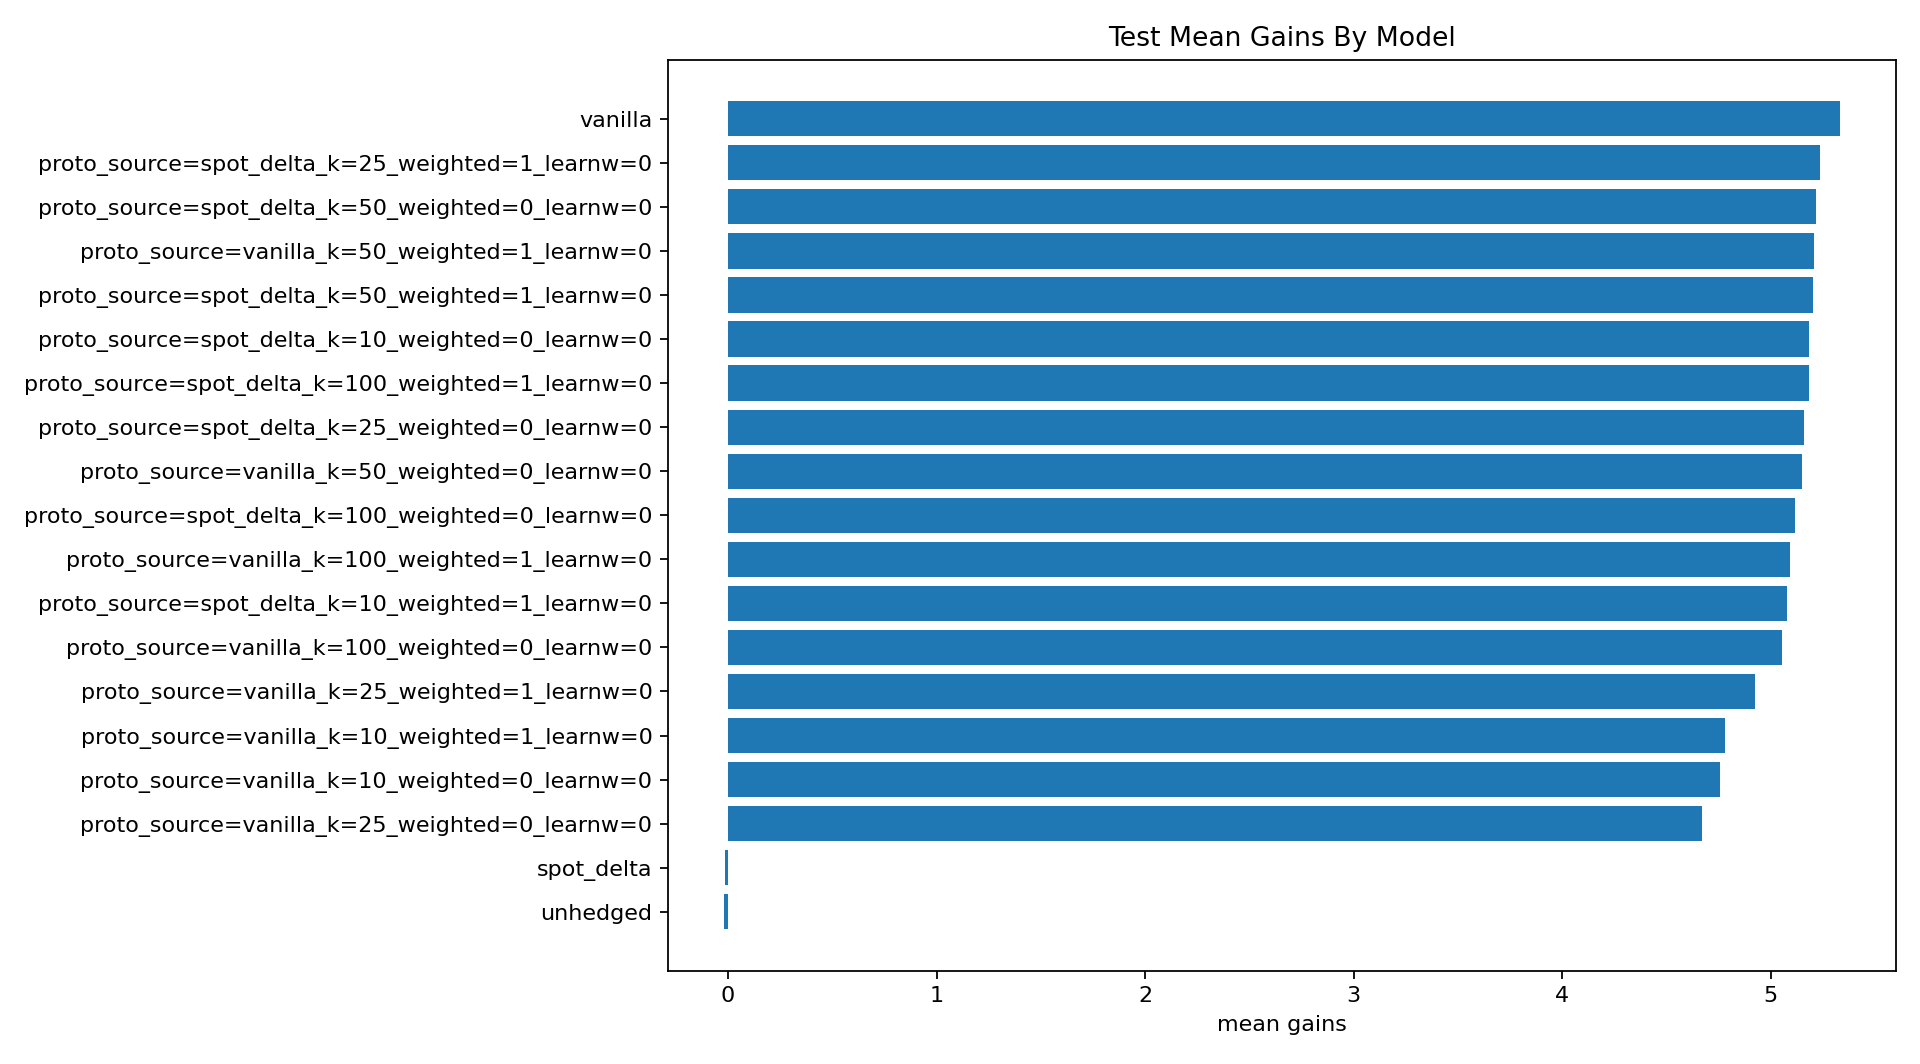

/Users/yaniszaim/deephedging/.deephedging_real_runs/real_data_sweep_focused_800/sweep_test_cvar05.png


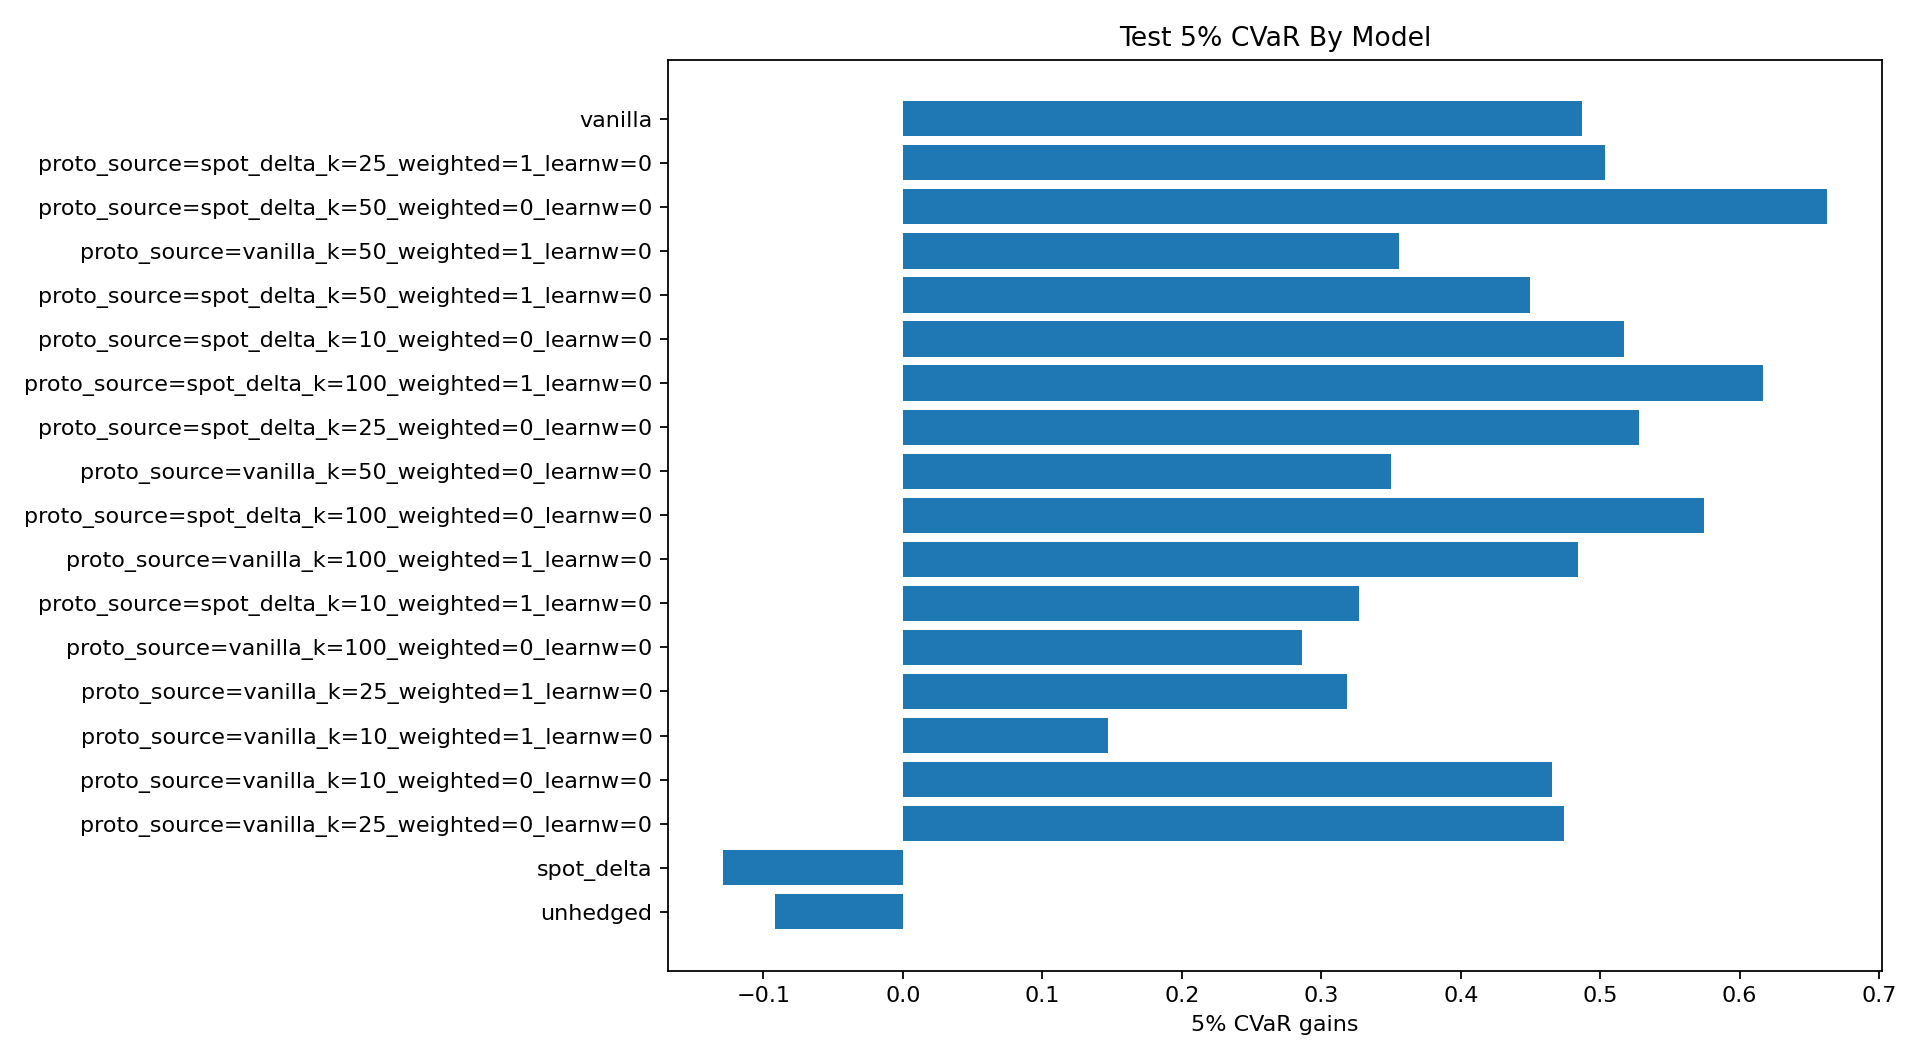

/Users/yaniszaim/deephedging/.deephedging_real_runs/real_data_sweep_focused_800/sweep_test_shortfall_prob.png


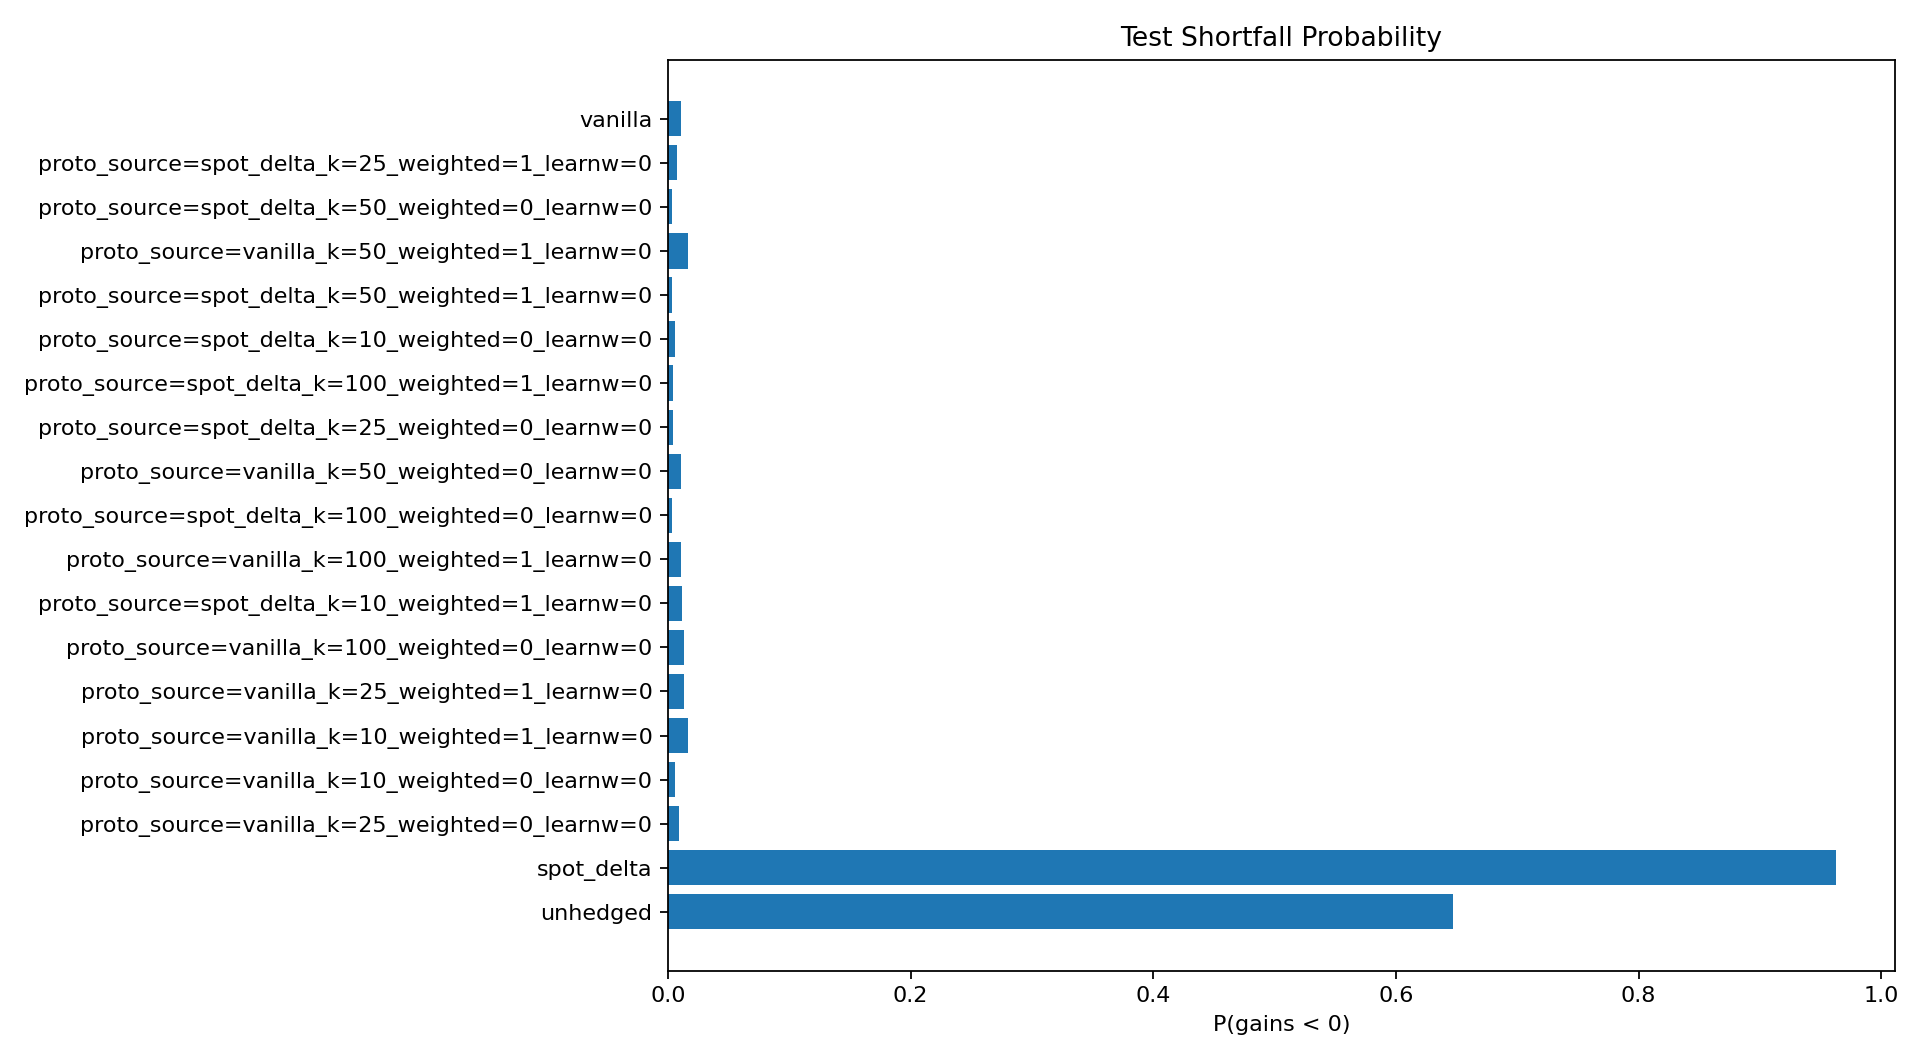

/Users/yaniszaim/deephedging/.deephedging_real_runs/real_data_sweep_focused_800/proto_gains_vs_n_prototypes.png


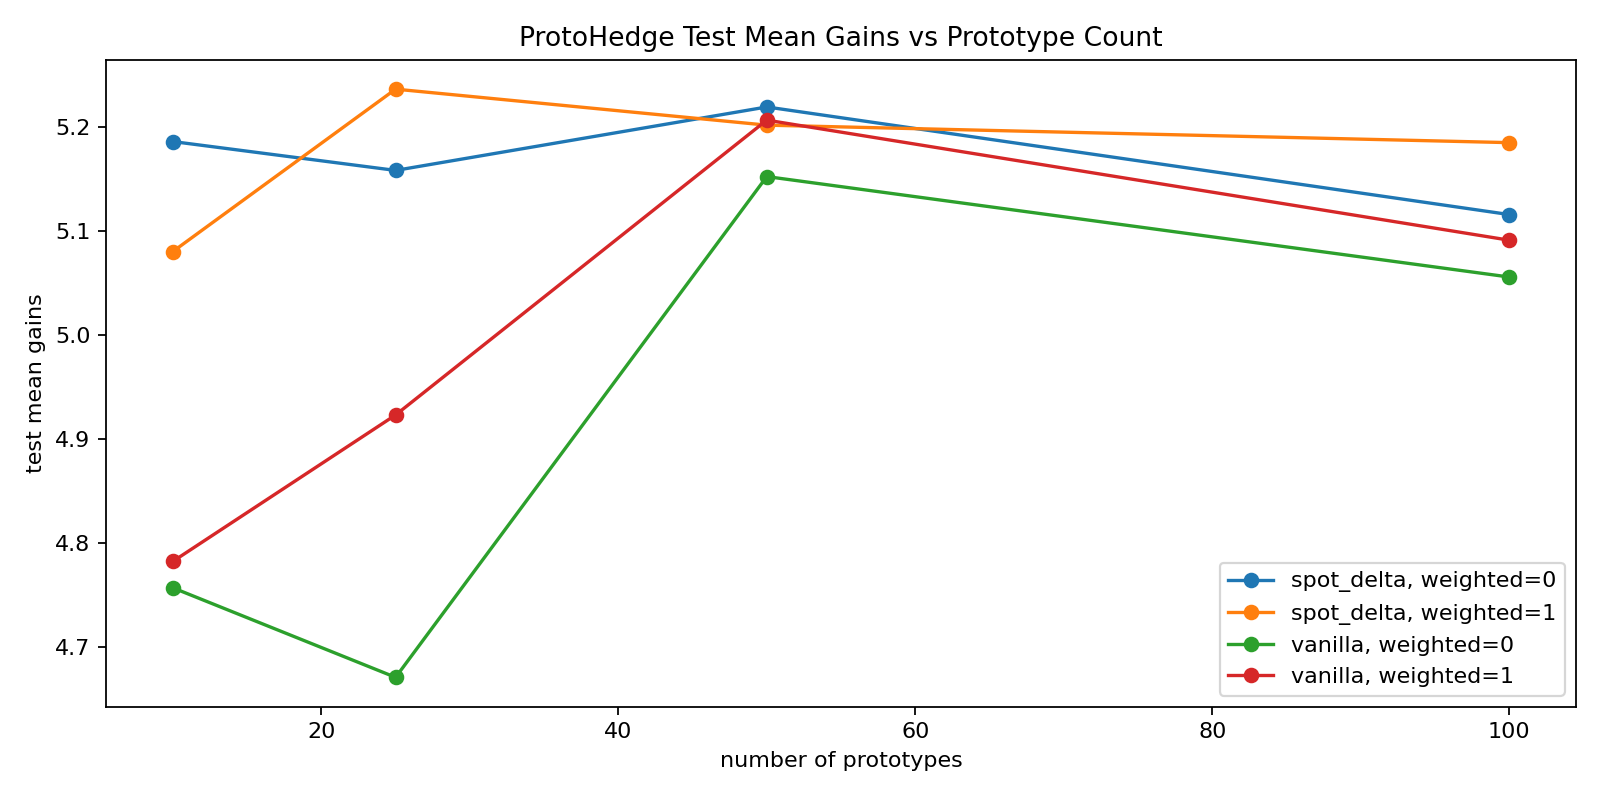

/Users/yaniszaim/deephedging/.deephedging_real_runs/real_data_sweep_focused_800/proto_cvar05_vs_n_prototypes.png


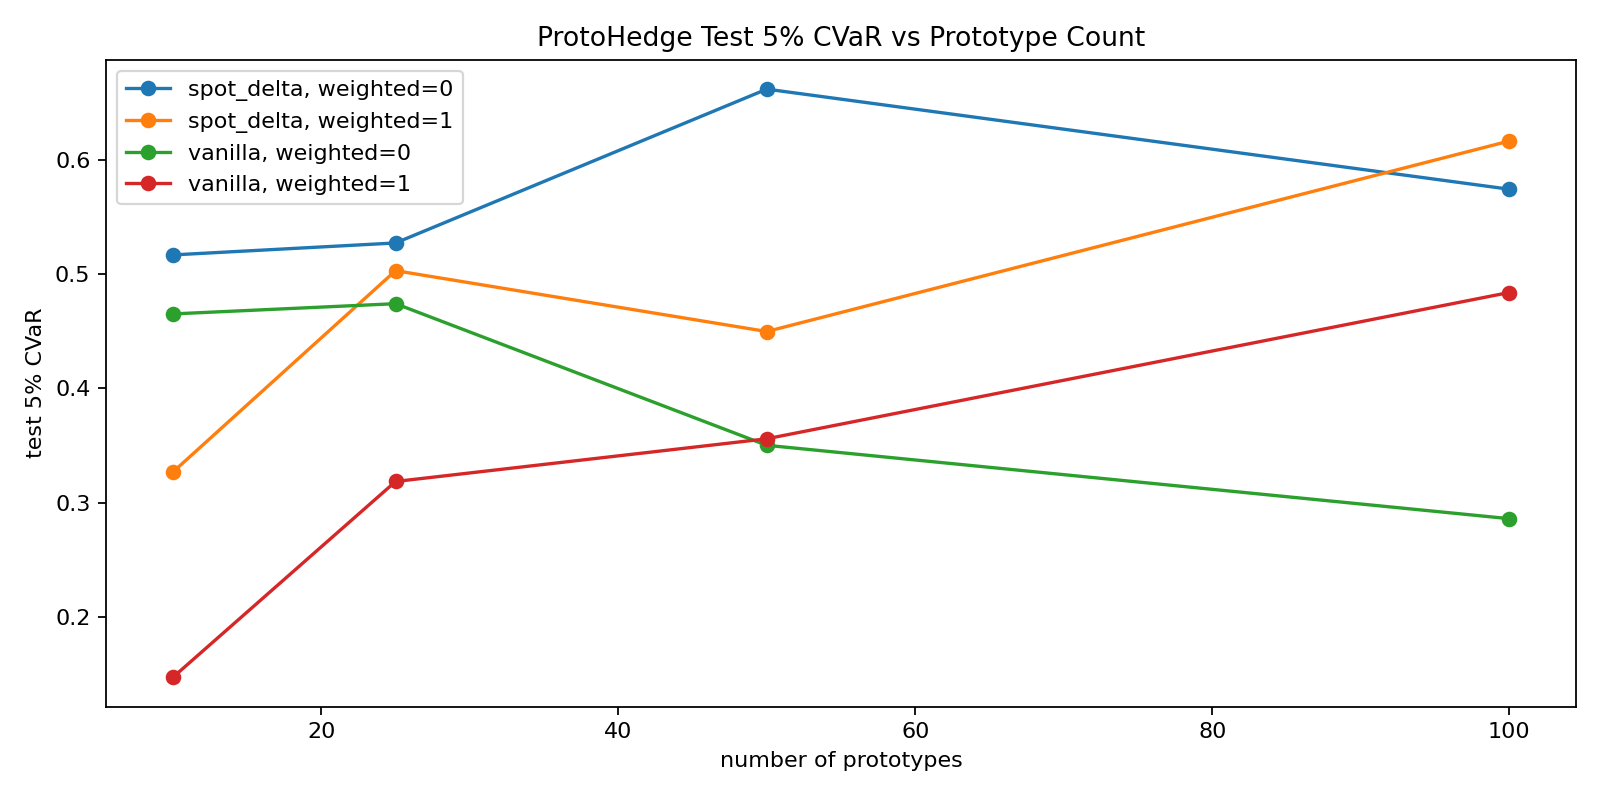

In [167]:
from IPython.display import Image, display as ipy_display, Markdown

summary_path = SWEEP_OUTPUT_DIR / "sweep_test_summary.csv"
paper_comparison_path = SWEEP_OUTPUT_DIR / "paper_model_comparison.csv"
paper_best_path = SWEEP_OUTPUT_DIR / "paper_best_models.csv"
paper_selected_path = SWEEP_OUTPUT_DIR / "paper_selected_table.csv"
interpretation_path = SWEEP_OUTPUT_DIR / "interpretation.md"

if summary_path.exists():
    sweep_summary_df = pd.read_csv(summary_path)
    display_cols = [
        "model", "model_family", "prototype_source", "n_prototypes", "weighted_similarity",
        "gains_mean_avg", "gains_p05_avg", "gains_cvar05_avg", "shortfall_prob_avg",
        "pct_at_any_position_bound_avg", "pct_paths_touch_any_position_bound_avg",
        "delta_abs_max_avg", "action_abs_mean_avg", "n_runs",
    ]
    display_cols = [c for c in display_cols if c in sweep_summary_df.columns]
    display(sweep_summary_df[display_cols].head(30))
else:
    sweep_summary_df = None
    print("No sweep summary found yet:", summary_path)

if paper_best_path.exists():
    paper_best_df = pd.read_csv(paper_best_path)
    display_cols = [
        "selection", "model", "model_family", "prototype_source", "n_prototypes", "weighted_similarity",
        "gains_mean_avg", "gains_cvar05_avg", "shortfall_prob_avg",
        "pct_at_any_position_bound_avg", "pct_paths_touch_any_position_bound_avg",
        "gains_mean_avg_minus_vanilla", "gains_mean_avg_minus_unhedged", "gains_mean_avg_minus_spot_delta",
        "n_runs",
    ]
    display_cols = [c for c in display_cols if c in paper_best_df.columns]
    print("Best model selections:")
    display(paper_best_df[display_cols])

if paper_selected_path.exists():
    paper_selected_df = pd.read_csv(paper_selected_path)
    display_cols = [
        "model", "model_family", "prototype_source", "n_prototypes", "weighted_similarity",
        "gains_mean_avg", "gains_cvar05_avg", "shortfall_prob_avg",
        "pct_at_any_position_bound_avg", "pct_paths_touch_any_position_bound_avg",
        "gains_mean_avg_minus_vanilla", "gains_cvar05_avg_minus_vanilla", "n_runs",
    ]
    display_cols = [c for c in display_cols if c in paper_selected_df.columns]
    print("Paper selected comparison table:")
    display(paper_selected_df[display_cols])

if interpretation_path.exists():
    ipy_display(Markdown(interpretation_path.read_text()))

plot_files = [
    "sweep_test_gains_mean.png",
    "sweep_test_cvar05.png",
    "sweep_test_shortfall_prob.png",
    "sweep_test_bound_saturation.png",
    "proto_gains_vs_n_prototypes.png",
    "proto_cvar05_vs_n_prototypes.png",
]
for filename in plot_files:
    path = SWEEP_OUTPUT_DIR / filename
    if path.exists():
        print(path)
        ipy_display(Image(filename=str(path)))

## 23. Sweep-Level Interpretation Template

Use this template after the sweep finishes:

- If vanilla wins mean and tail while ProtoHedge only beats unhedged, then ProtoHedge is mechanically useful but not yet competitive.
- If some ProtoHedge configuration beats unhedged and spot-delta but not vanilla, the next knob is prototype action learning/initialization rather than data integration.
- If ProtoHedge matches vanilla mean but has worse CVaR, it may be learning an average hedge but missing stress regimes.
- If ProtoHedge matches vanilla mean and CVaR with fewer/interpretable prototypes, that is the paper-level result we want.
- If ProtoHedge wins on tail metrics but only by living on the cumulative position bounds, that is not yet the right result.
- If the winning ProtoHedge config uses only a tiny number of prototypes, the interpretability story is stronger.
- If the winning config requires many prototypes and still uses them diffusely, the model may be drifting back toward a less interpretable approximation.

In the larger picture, this sweep is the bridge from "we ported ProtoHedge to PyTorch and made real data load" to "we have empirical evidence about whether prototype-based hedging is a viable interpretable alternative to vanilla Deep Hedging on historical data."

The next concrete run is `SWEEP_PRESET = "focused_original_epochs"`, which uses all paths, step-mode hedge increments, 800 epochs, and the prototype sources that were most promising in the pilot. If that result remains positive and not bound-saturated, move to `SWEEP_PRESET = "paper_original_epochs"` for multiple seeds.